In [1]:
import os
import glob
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import xarray as xr
import scipy.stats as st
from matplotlib.colors import BoundaryNorm
# from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas
# from matplotlib.figure import Figure
import matplotlib.gridspec as gridspec
import pandas as pd
import datetime
import copy
from scipy.stats import linregress
import seaborn as sns
import colorcet as cc
from sklearn.neighbors import KernelDensity
from scipy.ndimage import label, binary_dilation, generate_binary_structure, filters, iterate_structure
import warnings

In [2]:
xr.__version__

'2023.5.0'

In [3]:
def list_dirs(in_dir):
    """
    List sub-directories.
    """
    dirs = []
    for it in os.scandir(in_dir):
        if it.is_dir():
            dirs.append(it.path)
    return dirs

def find_lasso_files(start_dates, root_datadir, in_basename, domain):
    files = []
    # Loop over dates
    for ii in range(0, len(start_dates)):
        # Get sub-directories (cases)
        idate = start_dates[ii]
        case_dirs = list_dirs(f'{root_datadir}/{idate}/')
        if len(case_dirs) > 0:
            # Loop over cases
            for icase in case_dirs:
                # Find config sub-directories
                # config_dirs = list_dirs(icase)
                config_dirs = [f'{icase}/base/']
                if len(config_dirs) > 0:
                    # Loop over configs
                    for iconfig in config_dirs:
                        # Find track stats file
                        fname = sorted(glob.glob(f'{iconfig}/{domain}/stats/{in_basename}*nc'))
                        if len(fname) > 0:
                            files.append(fname[0])
    return files

In [4]:
# LASSO case dates
start_dates = [
    "20181129", 
    "20181204",
    "20181205", 
    "20181219", 
    "20190122", 
    # "20190123",
    "20190125",
    "20190129",
    "20190208",
]

# LASSO tracking directory
rootdir_les = '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/'
rootdir_meso = '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso/'
in_basename = 'trackstats_20'
in_basename_w = 'stats_3d_w_'
in_basename_env = 'stats_1d_env_'

figdir = '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures/'

# Domain 4 boundaries
# lon_range = [-65.4, -63.1]
# lat_range = [-33.3, -30.8]
lon_range = [-65., -63.1]
lat_range = [-33., -30.8]

# Find LASSO files
files_d2 = find_lasso_files(start_dates, rootdir_meso, in_basename, 'd2')
files_d3 = find_lasso_files(start_dates, rootdir_les, in_basename, 'd3')
files_d4 = find_lasso_files(start_dates, rootdir_les, in_basename, 'd4')
wfiles_d2 = find_lasso_files(start_dates, rootdir_meso, in_basename_w, 'd2')
wfiles_d3 = find_lasso_files(start_dates, rootdir_les, in_basename_w, 'd3')
wfiles_d4 = find_lasso_files(start_dates, rootdir_les, in_basename_w, 'd4')
efiles_d2 = find_lasso_files(start_dates, rootdir_meso, in_basename_env, 'd2')
efiles_d3 = find_lasso_files(start_dates, rootdir_les, in_basename_env, 'd3')
efiles_d4 = find_lasso_files(start_dates, rootdir_les, in_basename_env, 'd4')

print(f'Number of stats files (D2): {len(files_d2)}')
print(f'Number of W files (D2): {len(wfiles_d2)}')
print(f'Number of ENV files (D2): {len(efiles_d2)}')

print(f'Number of stats files (D3): {len(files_d3)}')
print(f'Number of W files (D3): {len(wfiles_d3)}')
print(f'Number of ENV files (D3): {len(efiles_d3)}')

print(f'Number of stats files (D4): {len(files_d4)}')
print(f'Number of W files (D4): {len(wfiles_d4)}')
print(f'Number of ENV files (D4): {len(efiles_d4)}')

files_d2, files_d3, files_d4, wfiles_d2, wfiles_d3, wfiles_d4

Number of stats files (D2): 16
Number of W files (D2): 16
Number of ENV files (D2): 16
Number of stats files (D3): 16
Number of W files (D3): 16
Number of ENV files (D3): 16
Number of stats files (D4): 16
Number of W files (D4): 16
Number of ENV files (D4): 16


(['/gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso//20181129/gefs03/base//d2/stats/trackstats_20181129.1200_20181130.0000.nc',
  '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso//20181129/gefs18/base//d2/stats/trackstats_20181129.1200_20181130.0000.nc',
  '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso//20181129/gefs00/base//d2/stats/trackstats_20181129.1200_20181130.0000.nc',
  '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso//20181129/gefs09/base//d2/stats/trackstats_20181129.1200_20181130.0000.nc',
  '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso//20181204/gefs19/base//d2/stats/trackstats_20181204.1200_20181205.0000.nc',
  '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso//20181204/gefs18/base//d2/stats/trackstats_20181204.1200_20181205.0000.nc',
  '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso//20181205/gefs01/base//d2/stats/trackstats_20181205.1200_20181206.0000.nc',
  '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso//20181219/eda09/base//d2/stats/trackstats_20181219.1200_20181220.000

## Read & combine data files

In [5]:
# Read track data (LASSO D2)
dst_d2 = xr.open_mfdataset(files_d2, concat_dim='tracks', combine='nested', engine='netcdf4')
# Renumber tracks to make it continuous
ntracks_d2 = dst_d2.sizes['tracks']
dst_d2['tracks'] = np.arange(0, ntracks_d2)
print(f'Number of tracks (D2): {ntracks_d2}')

# Read W data (LASSO D2)
dsw_d2 = xr.open_mfdataset(wfiles_d2, concat_dim='tracks', combine='nested')
# Renumber tracks to make it continuous
dsw_d2['tracks'] = np.arange(0, ntracks_d2)

# Read ENV data (LASSO D2)
dse_d2 = xr.open_mfdataset(efiles_d2, concat_dim='tracks', combine='nested')
dse_d2['tracks'] = np.arange(0, ntracks_d2)
dse_d2 = dse_d2.rename({'z': 'height'})

# Combine 2D and 3D datasets by coordinates
ds_d2 = xr.combine_by_coords([dst_d2, dsw_d2, dse_d2], combine_attrs='drop_conflicts')
ntimes_d2 = ds_d2.sizes['times']
ds_d2

Number of tracks (D2): 5007


<xarray.Dataset>
Dimensions:                  (tracks: 5007, times: 212, height: 101, z: 40,
                              core: 20)
Coordinates:
  * tracks                   (tracks) int64 0 1 2 3 4 ... 5003 5004 5005 5006
  * times                    (times) int64 -12 -11 -10 -9 -8 ... 196 197 198 199
  * height                   (height) float64 0.0 200.0 400.0 ... 1.98e+04 2e+04
  * z                        (z) float64 250.0 500.0 750.0 ... 2e+04 2.1e+04
  * core                     (core) int64 0 1 2 3 4 5 6 ... 13 14 15 16 17 18 19
Data variables: (12/188)
    temperature              (tracks, times, height) float32 dask.array<chunksize=(219, 212, 101), meta=np.ndarray>
    qv                       (tracks, times, height) float32 dask.array<chunksize=(219, 212, 101), meta=np.ndarray>
    rh                       (tracks, times, height) float32 dask.array<chunksize=(219, 212, 101), meta=np.ndarray>
    pressure                 (tracks, times, height) float32 dask.array<chunksize=(219, 212, 101), meta=np.ndarray>
    u                        (tracks, times, height) float32 dask.array<chunksize=(219, 212, 101), meta=np.ndarray>
    v                        (tracks, times, height) float32 dask.array<chunksize=(219, 212, 101), meta=np.ndarray>
    ...                       ...
    start_split_tracknumber  (tracks) float64 dask.array<chunksize=(219,), meta=np.ndarray>
    start_split_timeindex    (tracks) float64 dask.array<chunksize=(219,), meta=np.ndarray>
    start_split_cloudnumber  (tracks) float64 dask.array<chunksize=(219,), meta=np.ndarray>
    end_merge_tracknumber    (tracks) float64 dask.array<chunksize=(219,), meta=np.ndarray>
    end_merge_timeindex      (tracks) float64 dask.array<chunksize=(219,), meta=np.ndarray>
    end_merge_cloudnumber    (tracks) float64 dask.array<chunksize=(219,), meta=np.ndarray>
Attributes:
    title:                 Tracked cell W statistics
    source_trackfile:      /gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso/201...
    startdate:             20181129.1200
    enddate:               20181130.0000
    timegap_hour:          0.5
    time_resolution_hour:  0.08333
    pixel_radius_km:       2.5

In [6]:
# ds = xr.open_dataset(files_d2[0], engine='netcdf4')
# dse_d2.LCL_height_mu.sel(times=-3).plot.hist()

In [7]:
# Read track data (LASSO D3)
dst_d3 = xr.open_mfdataset(files_d3, concat_dim='tracks', combine='nested', engine='netcdf4')
# Renumber tracks to make it continuous
ntracks_d3 = dst_d3.sizes['tracks']
dst_d3['tracks'] = np.arange(0, ntracks_d3)
print(f'Number of tracks (D3): {ntracks_d3}')

# Read W data (LASSO D3)
dsw_d3 = xr.open_mfdataset(wfiles_d3, concat_dim='tracks', combine='nested')
# Renumber tracks to make it continuous
dsw_d3['tracks'] = np.arange(0, ntracks_d3)

# Read ENV data (LASSO D3)
dse_d3 = xr.open_mfdataset(efiles_d3, concat_dim='tracks', combine='nested')
dse_d3['tracks'] = np.arange(0, ntracks_d3)
dse_d3 = dse_d3.rename({'z': 'height'})

# Combine 2D and 3D datasets by coordinates
ds_d3 = xr.combine_by_coords([dst_d3, dsw_d3, dse_d3], combine_attrs='drop_conflicts')
ntimes_d3 = ds_d3.sizes['times']
ds_d3

Number of tracks (D3): 8348


<xarray.Dataset>
Dimensions:                  (tracks: 8348, times: 212, height: 101, z: 40,
                              core: 10)
Coordinates:
  * tracks                   (tracks) int64 0 1 2 3 4 ... 8344 8345 8346 8347
  * times                    (times) int64 -12 -11 -10 -9 -8 ... 196 197 198 199
  * height                   (height) float64 0.0 200.0 400.0 ... 1.98e+04 2e+04
  * z                        (z) float64 250.0 500.0 750.0 ... 2e+04 2.1e+04
  * core                     (core) int64 0 1 2 3 4 5 6 7 8 9
Data variables: (12/188)
    temperature              (tracks, times, height) float32 dask.array<chunksize=(369, 212, 101), meta=np.ndarray>
    qv                       (tracks, times, height) float32 dask.array<chunksize=(369, 212, 101), meta=np.ndarray>
    rh                       (tracks, times, height) float32 dask.array<chunksize=(369, 212, 101), meta=np.ndarray>
    pressure                 (tracks, times, height) float32 dask.array<chunksize=(369, 212, 101), meta=np.ndarray>
    u                        (tracks, times, height) float32 dask.array<chunksize=(369, 212, 101), meta=np.ndarray>
    v                        (tracks, times, height) float32 dask.array<chunksize=(369, 212, 101), meta=np.ndarray>
    ...                       ...
    start_split_tracknumber  (tracks) float64 dask.array<chunksize=(369,), meta=np.ndarray>
    start_split_timeindex    (tracks) float64 dask.array<chunksize=(369,), meta=np.ndarray>
    start_split_cloudnumber  (tracks) float64 dask.array<chunksize=(369,), meta=np.ndarray>
    end_merge_tracknumber    (tracks) float64 dask.array<chunksize=(369,), meta=np.ndarray>
    end_merge_timeindex      (tracks) float64 dask.array<chunksize=(369,), meta=np.ndarray>
    end_merge_cloudnumber    (tracks) float64 dask.array<chunksize=(369,), meta=np.ndarray>
Attributes:
    title:                 Tracked cell W statistics
    source_trackfile:      /gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/2018...
    startdate:             20181129.1200
    enddate:               20181130.0000
    timegap_hour:          0.5
    time_resolution_hour:  0.08333
    pixel_radius_km:       0.5

In [8]:
# Read track data (LASSO D4)
dst_d4 = xr.open_mfdataset(files_d4, concat_dim='tracks', combine='nested', engine='netcdf4')
# Renumber tracks to make it continuous
ntracks_d4 = dst_d4.sizes['tracks']
dst_d4['tracks'] = np.arange(0, ntracks_d4)
print(f'Number of tracks (D4): {ntracks_d4}')

# Read W data (LASSO D4)
dsw_d4 = xr.open_mfdataset(wfiles_d4, concat_dim='tracks', combine='nested')
# Renumber tracks to make it continuous
dsw_d4['tracks'] = np.arange(0, ntracks_d4)

# Read ENV data (LASSO D4)
dse_d4 = xr.open_mfdataset(efiles_d4, concat_dim='tracks', combine='nested')
dse_d4['tracks'] = np.arange(0, ntracks_d4)
dse_d4 = dse_d4.rename({'z': 'height'})

# Combine 2D and 3D datasets by coordinates
ds_d4 = xr.combine_by_coords([dst_d4, dsw_d4, dse_d4], combine_attrs='drop_conflicts')
ntimes_d4 = ds_d4.sizes['times']
ds_d4

Number of tracks (D4): 6463


<xarray.Dataset>
Dimensions:                  (tracks: 6463, times: 212, height: 101, z: 40,
                              core: 10)
Coordinates:
  * tracks                   (tracks) int64 0 1 2 3 4 ... 6459 6460 6461 6462
  * times                    (times) int64 -12 -11 -10 -9 -8 ... 196 197 198 199
  * height                   (height) float64 0.0 200.0 400.0 ... 1.98e+04 2e+04
  * z                        (z) float64 250.0 500.0 750.0 ... 2e+04 2.1e+04
  * core                     (core) int64 0 1 2 3 4 5 6 7 8 9
Data variables: (12/188)
    temperature              (tracks, times, height) float32 dask.array<chunksize=(295, 212, 101), meta=np.ndarray>
    qv                       (tracks, times, height) float32 dask.array<chunksize=(295, 212, 101), meta=np.ndarray>
    rh                       (tracks, times, height) float32 dask.array<chunksize=(295, 212, 101), meta=np.ndarray>
    pressure                 (tracks, times, height) float32 dask.array<chunksize=(295, 212, 101), meta=np.ndarray>
    u                        (tracks, times, height) float32 dask.array<chunksize=(295, 212, 101), meta=np.ndarray>
    v                        (tracks, times, height) float32 dask.array<chunksize=(295, 212, 101), meta=np.ndarray>
    ...                       ...
    start_split_tracknumber  (tracks) float64 dask.array<chunksize=(295,), meta=np.ndarray>
    start_split_timeindex    (tracks) float64 dask.array<chunksize=(295,), meta=np.ndarray>
    start_split_cloudnumber  (tracks) float64 dask.array<chunksize=(295,), meta=np.ndarray>
    end_merge_tracknumber    (tracks) float64 dask.array<chunksize=(295,), meta=np.ndarray>
    end_merge_timeindex      (tracks) float64 dask.array<chunksize=(295,), meta=np.ndarray>
    end_merge_cloudnumber    (tracks) float64 dask.array<chunksize=(295,), meta=np.ndarray>
Attributes:
    title:                 Tracked cell W statistics
    source_trackfile:      /gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/2018...
    startdate:             20181129.1200
    enddate:               20181130.0000
    timegap_hour:          0.5
    time_resolution_hour:  0.08333
    pixel_radius_km:       0.5

In [9]:
# # Read track data (LASSO D2)
# dst_d2 = xr.open_mfdataset(files_d2, concat_dim='tracks', combine='nested', engine='netcdf4')
# # Renumber tracks to make it continuous
# ntracks_d2 = dst_d2.sizes['tracks']
# dst_d2['tracks'] = np.arange(0, ntracks_d2)
# print(f'Number of tracks (D2): {ntracks_d2}')

# # Read W data (LASSO D2)
# dsw_d2 = xr.open_mfdataset(wfiles_d2, concat_dim='tracks', combine='nested')
# # Renumber tracks to make it continuous
# dsw_d2['tracks'] = np.arange(0, ntracks_d2)

# # Combine 2D and 3D datasets by coordinates
# ds_d2 = xr.combine_by_coords([dst_d2, dsw_d2], combine_attrs='drop_conflicts')
# ntimes_d2 = ds_d2.sizes['times']
# ds_d2

In [10]:
# # Read track data (LASSO D3)
# dst_d3 = xr.open_mfdataset(files_d3, concat_dim='tracks', combine='nested')
# # Renumber tracks to make it continuous
# ntracks_d3 = dst_d3.sizes['tracks']
# dst_d3['tracks'] = np.arange(0, ntracks_d3)
# print(f'Number of tracks (D3): {ntracks_d3}')

# # Read W data (LASSO D3)
# dsw_d3 = xr.open_mfdataset(wfiles_d3, concat_dim='tracks', combine='nested')
# # Renumber tracks to make it continuous
# dsw_d3['tracks'] = np.arange(0, ntracks_d3)

# # Combine 2D and 3D datasets by coordinates
# ds_d3 = xr.combine_by_coords([dst_d3, dsw_d3], combine_attrs='drop_conflicts')
# ntimes_d3 = ds_d3.sizes['times']
# ds_d3

In [11]:
# # Read track data (LASSO D4)
# # dst_d4 = xr.open_mfdataset(files_d4, concat_dim='tracks', combine='nested').load()
# dst_d4 = xr.open_mfdataset(files_d4, concat_dim='tracks', combine='nested')
# # Renumber tracks to make it continuous
# ntracks_d4 = dst_d4.sizes['tracks']
# dst_d4['tracks'] = np.arange(0, ntracks_d4)
# print(f'Number of tracks (d4): {ntracks_d4}')

# # Read W data (LASSO D4)
# # dsw_d4 = xr.open_mfdataset(wfiles_d4, concat_dim='tracks', combine='nested').load()
# dsw_d4 = xr.open_mfdataset(wfiles_d4, concat_dim='tracks', combine='nested')
# # Renumber tracks to make it continuous
# dsw_d4['tracks'] = np.arange(0, ntracks_d4)

# # Combine 2D and 3D datasets by coordinates
# ds_d4 = xr.combine_by_coords([dst_d4, dsw_d4], combine_attrs='drop_conflicts')
# # Trim times dimension to match D3
# ds_d4 = ds_d4.isel(times=slice(0, ntimes_d3))
# ds_d4

## Subset tracks

In [12]:
# Get track min/max lat/lon
minlon_d2 = ds_d2['meanlon'].min(dim='times').load()
maxlon_d2 = ds_d2['meanlon'].max(dim='times').load()
minlat_d2 = ds_d2['meanlat'].min(dim='times').load()
maxlat_d2 = ds_d2['meanlat'].max(dim='times').load()
# Subset d2 tracks that are within D4 boundary
ds_d2 = ds_d2.where((minlon_d2 >= min(lon_range)) & (maxlon_d2 <= max(lon_range)) & \
                    (minlat_d2 >= min(lat_range)) & (maxlat_d2 <= max(lat_range)), drop=True)
# Renumber tracks to make it continuous
ntracks_d2 = ds_d2.sizes['tracks']
ds_d2['tracks'] = np.arange(0, ntracks_d2)
print(f'Number of tracks (D2): {ntracks_d2}')

Number of tracks (D2): 2726


In [13]:
# Get track min/max lat/lon
minlon_d3 = ds_d3['meanlon'].min(dim='times').load()
maxlon_d3 = ds_d3['meanlon'].max(dim='times').load()
minlat_d3 = ds_d3['meanlat'].min(dim='times').load()
maxlat_d3 = ds_d3['meanlat'].max(dim='times').load()
# Subset D3 tracks that are within D4 boundary
ds_d3 = ds_d3.where((minlon_d3 >= min(lon_range)) & (maxlon_d3 <= max(lon_range)) & \
                    (minlat_d3 >= min(lat_range)) & (maxlat_d3 <= max(lat_range)), drop=True)
# Renumber tracks to make it continuous
ntracks_d3 = ds_d3.sizes['tracks']
ds_d3['tracks'] = np.arange(0, ntracks_d3)
print(f'Number of tracks (D3): {ntracks_d3}')

Number of tracks (D3): 4518


In [14]:
# Get track min/max lat/lon
minlon_d4 = ds_d4['meanlon'].min(dim='times').load()
maxlon_d4 = ds_d4['meanlon'].max(dim='times').load()
minlat_d4 = ds_d4['meanlat'].min(dim='times').load()
maxlat_d4 = ds_d4['meanlat'].max(dim='times').load()
# Subset d4 tracks that are within D4 boundary
ds_d4 = ds_d4.where((minlon_d4 >= min(lon_range)) & (maxlon_d4 <= max(lon_range)) & \
                    (minlat_d4 >= min(lat_range)) & (maxlat_d4 <= max(lat_range)), drop=True)
# Renumber tracks to make it continuous
ntracks_d4 = ds_d4.sizes['tracks']
ds_d4['tracks'] = np.arange(0, ntracks_d4)
print(f'Number of tracks (D4): {ntracks_d4}')

Number of tracks (D4): 4043


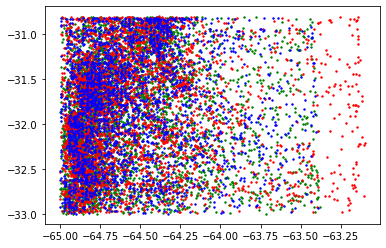

In [15]:
plt.scatter(ds_d3['meanlon'].mean(dim='times'), ds_d3['meanlat'].mean(dim='times'), s=2, c='g')
plt.scatter(ds_d4['meanlon'].mean(dim='times'), ds_d4['meanlat'].mean(dim='times'), s=2, c='r')
plt.scatter(ds_d2['meanlon'].mean(dim='times'), ds_d2['meanlat'].mean(dim='times'), s=2, c='b')

In [16]:
minlon_d4 = ds_d4['meanlon'].min().values
maxlon_d4 = ds_d4['meanlon'].max().values
minlat_d4 = ds_d4['meanlat'].min().values
maxlat_d4 = ds_d4['meanlat'].max().values
print(minlon_d4, maxlon_d4, minlat_d4, maxlat_d4)
print(lon_range, lat_range)

-64.99961 -63.10074 -32.998272 -30.800056
[-65.0, -63.1] [-33.0, -30.8]


## Find merge/split track indices

In [17]:
def find_merge_split_tracks(ds):
    """
    Find merge/split track indices.
    """
    # non-split tracks
    idx_nsplit = np.isnan(ds.start_split_cloudnumber.load())
    # non-merge tracks
    idx_nmerge = np.isnan(ds.end_merge_cloudnumber.load())
    # non-merge and non-split tracks
    idx_nms = np.isnan(ds.start_split_cloudnumber.load()) & np.isnan(ds.end_merge_cloudnumber.load())
    # merge or split tracks
    idx_ms = ~np.isnan(ds.start_split_cloudnumber.load()) | ~np.isnan(ds.end_merge_cloudnumber.load())
    # Group outputs to dictionary
    out_dict = {
        'ms': idx_ms,
        'nms': idx_nms,
        'nm': idx_nmerge,
        'ns': idx_nsplit,
    }
    return out_dict

In [18]:
tid_d2 = find_merge_split_tracks(ds_d2)
tid_d3 = find_merge_split_tracks(ds_d3)
tid_d4 = find_merge_split_tracks(ds_d4)

In [19]:
# ntracks_nms_d2 = np.count_nonzero(tid_d2['nms'] == True)
# ntracks_ns_d2 = np.count_nonzero(tid_d2['ns'] == True)
# print(f'D2 non-merge-split tracks: {ntracks_nms_d2}, non-split tracks: {ntracks_ns_d2}')

In [20]:
# ntracks_nms_d3 = np.count_nonzero(tid_d3['nms'] == True)
# ntracks_ns_d3 = np.count_nonzero(tid_d3['ns'] == True)
# print(f'D3 non-merge-split tracks: {ntracks_nms_d3}, non-split tracks: {ntracks_ns_d3}')

In [21]:
# ntracks_nms_d4 = np.count_nonzero(tid_d4['nms'] == True)
# ntracks_ns_d4 = np.count_nonzero(tid_d4['ns'] == True)
# print(f'D4 non-merge-split tracks: {ntracks_nms_d4}, non-split tracks: {ntracks_ns_d4}')

## Subset DataSets with non-merge/non-split tracks (for shallow cells)

In [22]:
dsnms_d2 = ds_d2.isel(tracks=tid_d2['nms'])
dsnms_d3 = ds_d3.isel(tracks=tid_d3['nms'])
dsnms_d4 = ds_d4.isel(tracks=tid_d4['nms'])

# Get number of tracks
ntracks_nms_d2 = dsnms_d2.sizes['tracks']
ntracks_nms_d3 = dsnms_d3.sizes['tracks']
ntracks_nms_d4 = dsnms_d4.sizes['tracks']
print(f'D2 non-merge-split tracks: {ntracks_nms_d2}')
print(f'D3 non-merge-split tracks: {ntracks_nms_d3}')
print(f'D4 non-merge-split tracks: {ntracks_nms_d4}')

D2 non-merge-split tracks: 1039
D3 non-merge-split tracks: 2140
D4 non-merge-split tracks: 2280


## Subset DataSets with non-split tracks (for deep cells)

In [23]:
dsns_d2 = ds_d2.isel(tracks=tid_d2['ns'])
dsns_d3 = ds_d3.isel(tracks=tid_d3['ns'])
dsns_d4 = ds_d4.isel(tracks=tid_d4['ns'])

ntracks_ns_d2 = dsns_d2.sizes['tracks']
ntracks_ns_d3 = dsns_d3.sizes['tracks']
ntracks_ns_d4 = dsns_d4.sizes['tracks']
print(f'D2 non-split tracks: {ntracks_ns_d2}')
print(f'D3 non-split tracks: {ntracks_ns_d3}')
print(f'D4 non-split tracks: {ntracks_ns_d4}')

D2 non-split tracks: 1525
D3 non-split tracks: 2818
D4 non-split tracks: 2833


In [24]:
# Get some constents common for all Datasets
ntimes = dsns_d2.dims['times']
nz = dsns_d2.dims['z']
ncores = dsns_d2.dims['core']

time_res = 5.0  # [min]
xtime = dsns_d2.times * time_res
height = dsns_d2.z / 1000.

In [25]:
# Get cell track lifetime: track_duration x time_resolution [min]
track_lifetime_d2 = dsns_d2['track_duration'].load() * time_res
track_lifetime_d3 = dsns_d3['track_duration'].load() * time_res
track_lifetime_d4 = dsns_d4['track_duration'].load() * time_res

maxETH_10dbz_d2 = dsns_d2['maxETH_10dbz'].load()
maxETH_10dbz_d3 = dsns_d3['maxETH_10dbz'].load()
maxETH_10dbz_d4 = dsns_d4['maxETH_10dbz'].load()

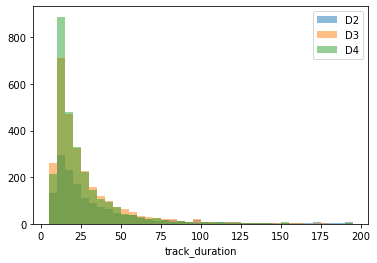

In [26]:
bins = np.arange(5,200,5)
track_lifetime_d2.plot.hist(bins=bins, alpha=0.5, label='D2')
track_lifetime_d3.plot.hist(bins=bins, alpha=0.5, label='D3')
track_lifetime_d4.plot.hist(bins=bins, alpha=0.5, label='D4')
plt.legend()

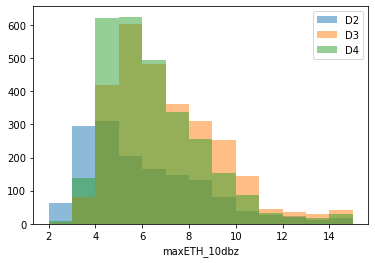

In [27]:
bins = np.arange(2,16,1)
maxETH_10dbz_d2.max(dim='times').plot.hist(bins=bins, alpha=0.5, label='D2')
maxETH_10dbz_d3.max(dim='times').plot.hist(bins=bins, alpha=0.5, label='D3')
maxETH_10dbz_d4.max(dim='times').plot.hist(bins=bins, alpha=0.5, label='D4')
plt.legend()

## Get lifetime-max 10dBZ ETH distributions & percentile values

In [28]:
ETH_percentiles = [0.33, 0.5, 0.66]
trackmaxETH_10dbz_d2 = maxETH_10dbz_d2.max(dim='times')
max10dbz_pts_d2 = trackmaxETH_10dbz_d2.quantile(ETH_percentiles, keep_attrs=True, skipna=True)
print(f"Max 10dBZ percentile values (D2): {max10dbz_pts_d2.values}")

Max 10dBZ percentile values (D2): [4.25 5.25 6.5 ]


In [29]:
trackmaxETH_10dbz_d3 = maxETH_10dbz_d3.max(dim='times')
max10dbz_pts_d3 = trackmaxETH_10dbz_d3.quantile(ETH_percentiles, keep_attrs=True, skipna=True)
print(f"Max 10dBZ percentile values (D3): {max10dbz_pts_d3.values}")

Max 10dBZ percentile values (D3): [5.5 6.5 7.5]


In [30]:
trackmaxETH_10dbz_d4 = maxETH_10dbz_d4.max(dim='times')
max10dbz_pts_d4 = trackmaxETH_10dbz_d4.quantile(ETH_percentiles, keep_attrs=True, skipna=True)
print(f"Max 10dBZ percentile values (D4): {max10dbz_pts_d4.values}")

Max 10dBZ percentile values (D4): [5.  6.  6.5]


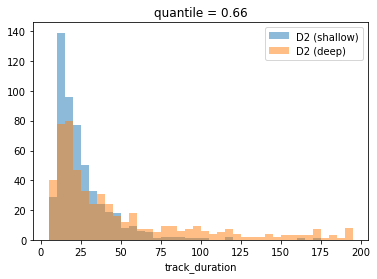

In [31]:
bins = np.arange(5,200,5)
track_lifetime_d2.where(trackmaxETH_10dbz_d2 <= max10dbz_pts_d2.sel(quantile=0.33), drop=True).plot.hist(bins=bins, alpha=0.5, label='D2 (shallow)')
track_lifetime_d2.where(trackmaxETH_10dbz_d2 >= max10dbz_pts_d2.sel(quantile=0.66), drop=True).plot.hist(bins=bins, alpha=0.5, label='D2 (deep)')
plt.legend()

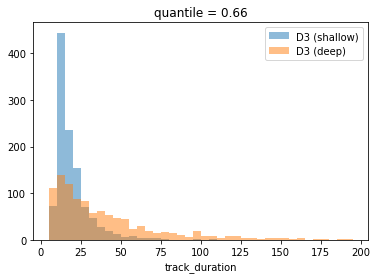

In [32]:
bins = np.arange(5,200,5)
track_lifetime_d3.where(trackmaxETH_10dbz_d3 <= max10dbz_pts_d3.sel(quantile=0.33), drop=True).plot.hist(bins=bins, alpha=0.5, label='D3 (shallow)')
track_lifetime_d3.where(trackmaxETH_10dbz_d3 >= max10dbz_pts_d3.sel(quantile=0.66), drop=True).plot.hist(bins=bins, alpha=0.5, label='D3 (deep)')
plt.legend()

In [33]:
# CoreArea_up_d2.shape, trackmaxETH_10dbz_d2.shape

# Define shallow vs. deep cells
## Include duration threshold to both shallow/deep cells

In [34]:
track_lifetime_d2.shape, trackmaxETH_10dbz_d2.shape

((1525,), (1525,))

In [35]:
track_lifetime_d2.min().values

array(5.)

In [36]:
# Define cell lifetime range for filtering, unit: [min]
# shallow_lifetime_range = [15,100]
shallow_lifetime_range = [10,200]
deep_lifetime_range = [10,200]

# Select percentiles to define shallow vs. deep cells
percentile_shallow = ETH_percentiles[0]
percentile_deep = ETH_percentiles[2]
print(f'Percentile thresholds for shallow: {percentile_shallow}, deep: {percentile_deep}')

Percentile thresholds for shallow: 0.33, deep: 0.66


In [37]:
# trackmaxETH_10dbz_d2.shape, dsns_d2.end_merge_cloudnumber.shape

D2 shallow 443
D2 deep 520


(array([  0.,   0.,   0.,   0.,   0.,   0.,  66., 134., 124.,  77.,  34.,
         27.,  23.,  12.,   7.,   8.,   0.,   4.,   4.]),
 array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19]),
 <BarContainer object of 19 artists>)

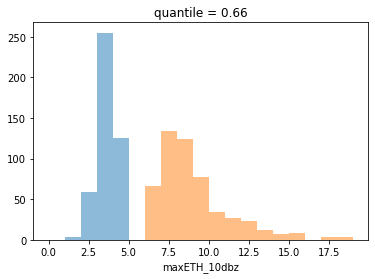

In [38]:
# Get shallow vs. deep cell/track IDs
# Shallow: 1. ETH; 2. Lifetime; 3. Not end as merging
cid_shallow_d2 = (
    (trackmaxETH_10dbz_d2 <= max10dbz_pts_d2.sel(quantile=percentile_shallow)) \
    & (track_lifetime_d2 >= min(shallow_lifetime_range)) \
    & (np.isnan(dsns_d2.end_merge_cloudnumber)) \
)
# Deep: 1. ETH; 2. Lifetime
cid_deep_d2 = (
    (trackmaxETH_10dbz_d2 >= max10dbz_pts_d2.sel(quantile=percentile_deep)) \
    & (track_lifetime_d2 >= min(deep_lifetime_range))
)

print('D2 shallow', np.count_nonzero(cid_shallow_d2 == True))
print('D2 deep', np.count_nonzero(cid_deep_d2 == True))

# Check ETH histogram for shallow vs. deep groups
bins = np.arange(0,20,1)
trackmaxETH_10dbz_d2.sel(tracks=cid_shallow_d2).plot.hist(bins=bins, alpha=0.5, label='D2 shallow')
trackmaxETH_10dbz_d2.sel(tracks=cid_deep_d2).plot.hist(bins=bins, alpha=0.5, label='D2 deep')

D3 shallow 1003
D3 deep 933


(array([  0.,   0.,   0.,   0.,   0.,   0.,   0., 163., 266., 226., 134.,
         44.,  31.,  25.,  21.,  18.,   1.,   0.,   4.]),
 array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19]),
 <BarContainer object of 19 artists>)

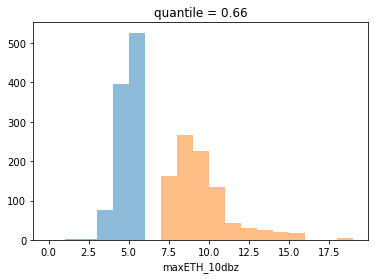

In [39]:
# Get shallow vs. deep cell/track IDs
# Shallow: 1. ETH; 2. Lifetime; 3. Not end as merging
cid_shallow_d3 = (
    (trackmaxETH_10dbz_d3 <= max10dbz_pts_d3.sel(quantile=percentile_shallow)) \
    & (track_lifetime_d3 >= min(shallow_lifetime_range)) \
    & (np.isnan(dsns_d3.end_merge_cloudnumber)) \
)
# Deep: 1. ETH; 2. Lifetime
cid_deep_d3 = (
    (trackmaxETH_10dbz_d3 >= max10dbz_pts_d3.sel(quantile=percentile_deep)) \
    & (track_lifetime_d3 >= min(deep_lifetime_range))
)

print('D3 shallow', np.count_nonzero(cid_shallow_d3 == True))
print('D3 deep', np.count_nonzero(cid_deep_d3 == True))

# Check ETH histogram for shallow vs. deep groups
bins = np.arange(0,20,1)
trackmaxETH_10dbz_d3.sel(tracks=cid_shallow_d3).plot.hist(bins=bins, alpha=0.5, label='d3 shallow')
trackmaxETH_10dbz_d3.sel(tracks=cid_deep_d3).plot.hist(bins=bins, alpha=0.5, label='d3 deep')

d4 shallow 909
d4 deep 1045


(array([  0.,   0.,   0.,   0.,   0.,   0., 198., 286., 232., 147.,  82.,
         31.,  18.,  16.,   8.,  16.,   2.,   4.,   4.]),
 array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19]),
 <BarContainer object of 19 artists>)

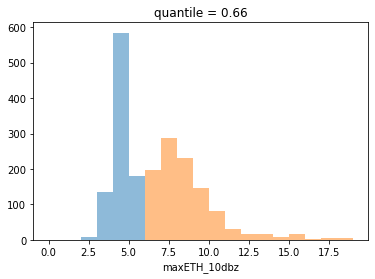

In [40]:
# Get shallow vs. deep cell/track IDs
# Shallow: 1. ETH; 2. Lifetime; 3. Not end as merging
cid_shallow_d4 = (
    (trackmaxETH_10dbz_d4 <= max10dbz_pts_d4.sel(quantile=percentile_shallow)) \
    & (track_lifetime_d4 >= min(shallow_lifetime_range)) \
    & (np.isnan(dsns_d4.end_merge_cloudnumber)) \
)
# Deep: 1. ETH; 2. Lifetime
cid_deep_d4 = (
    (trackmaxETH_10dbz_d4 >= max10dbz_pts_d4.sel(quantile=percentile_deep)) \
    & (track_lifetime_d4 >= min(deep_lifetime_range))
)

print('d4 shallow', np.count_nonzero(cid_shallow_d4 == True))
print('d4 deep', np.count_nonzero(cid_deep_d4 == True))

# Check ETH histogram for shallow vs. deep groups
bins = np.arange(0,20,1)
trackmaxETH_10dbz_d4.sel(tracks=cid_shallow_d4).plot.hist(bins=bins, alpha=0.5, label='d4 shallow')
trackmaxETH_10dbz_d4.sel(tracks=cid_deep_d4).plot.hist(bins=bins, alpha=0.5, label='d4 deep')

In [41]:
# # Get shallow vs. deep cell/track IDs
# cid_shallow_d3 = (trackmaxETH_10dbz_d3 <= max10dbz_pts_d3.sel(quantile=percentile_shallow)) & (track_lifetime_d3 >= min(shallow_lifetime_range))
# cid_deep_d3 = (trackmaxETH_10dbz_d3 >= max10dbz_pts_d3.sel(quantile=percentile_deep)) & (track_lifetime_d3 >= min(deep_lifetime_range))

# # Check ETH histogram for shallow vs. deep groups
# bins = np.arange(0,16,1)
# trackmaxETH_10dbz_d3.sel(tracks=cid_shallow_d3).plot.hist(bins=bins, alpha=0.5, label='d3 shallow')
# trackmaxETH_10dbz_d3.sel(tracks=cid_deep_d3).plot.hist(bins=bins, alpha=0.5, label='d3 deep')

In [42]:
# # Get shallow vs. deep cell/track IDs
# cid_shallow_d4 = (trackmaxETH_10dbz_d4 <= max10dbz_pts_d4.sel(quantile=percentile_shallow)) & (track_lifetime_d4 >= min(shallow_lifetime_range))
# cid_deep_d4 = (trackmaxETH_10dbz_d4 >= max10dbz_pts_d4.sel(quantile=percentile_deep)) & (track_lifetime_d4 >= min(deep_lifetime_range))

# # Check ETH histogram for shallow vs. deep groups
# bins = np.arange(0,16,1)
# trackmaxETH_10dbz_d4.sel(tracks=cid_shallow_d4).plot.hist(bins=bins, alpha=0.5, label='d4 shallow')
# trackmaxETH_10dbz_d4.sel(tracks=cid_deep_d4).plot.hist(bins=bins, alpha=0.5, label='d4 deep')

## Subset DataSets by shallow vs. deep tracks

In [43]:
dss_shallow_d2 = dsns_d2.sel(tracks=cid_shallow_d2)
dss_deep_d2 = dsns_d2.sel(tracks=cid_deep_d2)

# Filter updrafts above 10dBZ ETH + 1 km
maxETH_10dbz_shallow_d2 = dss_shallow_d2['maxETH_10dbz'].load()
CoreArea_up_shallow_d2 = dss_shallow_d2['CoreArea_up'].where(height <= maxETH_10dbz_shallow_d2+1).isel(core=0).load()
CoreMaxW_up_shallow_d2 = dss_shallow_d2['CoreMaxW_up'].where(height <= maxETH_10dbz_shallow_d2+1).isel(core=0).load()

maxETH_10dbz_deep_d2 = dss_deep_d2['maxETH_10dbz'].load()
CoreArea_up_deep_d2 = dss_deep_d2['CoreArea_up'].where(height <= maxETH_10dbz_deep_d2+1).isel(core=0).load()
CoreMaxW_up_deep_d2 = dss_deep_d2['CoreMaxW_up'].where(height <= maxETH_10dbz_deep_d2+1).isel(core=0).load()

In [44]:
dss_shallow_d3 = dsns_d3.sel(tracks=cid_shallow_d3)
dss_deep_d3 = dsns_d3.sel(tracks=cid_deep_d3)

# Filter updrafts above 10dBZ ETH + 1 km
maxETH_10dbz_shallow_d3 = dss_shallow_d3['maxETH_10dbz'].load()
CoreArea_up_shallow_d3 = dss_shallow_d3['CoreArea_up'].where(height <= maxETH_10dbz_shallow_d3+1).isel(core=0).load()
CoreMaxW_up_shallow_d3 = dss_shallow_d3['CoreMaxW_up'].where(height <= maxETH_10dbz_shallow_d3+1).isel(core=0).load()

maxETH_10dbz_deep_d3 = dss_deep_d3['maxETH_10dbz'].load()
CoreArea_up_deep_d3 = dss_deep_d3['CoreArea_up'].where(height <= maxETH_10dbz_deep_d3+1).isel(core=0).load()
CoreMaxW_up_deep_d3 = dss_deep_d3['CoreMaxW_up'].where(height <= maxETH_10dbz_deep_d3+1).isel(core=0).load()

In [45]:
dss_shallow_d4 = dsns_d4.sel(tracks=cid_shallow_d4)
dss_deep_d4 = dsns_d4.sel(tracks=cid_deep_d4)

# Filter updrafts above 10dBZ ETH + 1 km
maxETH_10dbz_shallow_d4 = dss_shallow_d4['maxETH_10dbz'].load()
CoreArea_up_shallow_d4 = dss_shallow_d4['CoreArea_up'].where(height <= maxETH_10dbz_shallow_d4+1).isel(core=0).load()
CoreMaxW_up_shallow_d4 = dss_shallow_d4['CoreMaxW_up'].where(height <= maxETH_10dbz_shallow_d4+1).isel(core=0).load()

maxETH_10dbz_deep_d4 = dss_deep_d4['maxETH_10dbz'].load()
CoreArea_up_deep_d4 = dss_deep_d4['CoreArea_up'].where(height <= maxETH_10dbz_deep_d4+1).isel(core=0).load()
CoreMaxW_up_deep_d4 = dss_deep_d4['CoreMaxW_up'].where(height <= maxETH_10dbz_deep_d4+1).isel(core=0).load()

In [46]:
# Number of sample at each time & height for all tracks
nsample_CoreArea_up_shallow_d2 = (CoreArea_up_shallow_d2 > 0).sum(dim='tracks')
nsample_CoreArea_up_deep_d2 = (CoreArea_up_deep_d2 > 0).sum(dim='tracks')
# Make 0 sample NaN
nsample_CoreArea_up_deep_d2 = nsample_CoreArea_up_deep_d2.where(nsample_CoreArea_up_deep_d2 > 0)
nsample_CoreArea_up_shallow_d2 = nsample_CoreArea_up_shallow_d2.where(nsample_CoreArea_up_shallow_d2 > 0)

In [47]:
# Number of sample at each time & height for all tracks
nsample_CoreArea_up_shallow_d3 = (CoreArea_up_shallow_d3 > 0).sum(dim='tracks')
nsample_CoreArea_up_deep_d3 = (CoreArea_up_deep_d3 > 0).sum(dim='tracks')
# Make 0 sample NaN
nsample_CoreArea_up_deep_d3 = nsample_CoreArea_up_deep_d3.where(nsample_CoreArea_up_deep_d3 > 0)
nsample_CoreArea_up_shallow_d3 = nsample_CoreArea_up_shallow_d3.where(nsample_CoreArea_up_shallow_d3 > 0)

In [48]:
# Number of sample at each time & height for all tracks
nsample_CoreArea_up_shallow_d4 = (CoreArea_up_shallow_d4 > 0).sum(dim='tracks')
nsample_CoreArea_up_deep_d4 = (CoreArea_up_deep_d4 > 0).sum(dim='tracks')
# Make 0 sample NaN
nsample_CoreArea_up_deep_d4 = nsample_CoreArea_up_deep_d4.where(nsample_CoreArea_up_deep_d4 > 0)
nsample_CoreArea_up_shallow_d4 = nsample_CoreArea_up_shallow_d4.where(nsample_CoreArea_up_shallow_d4 > 0)

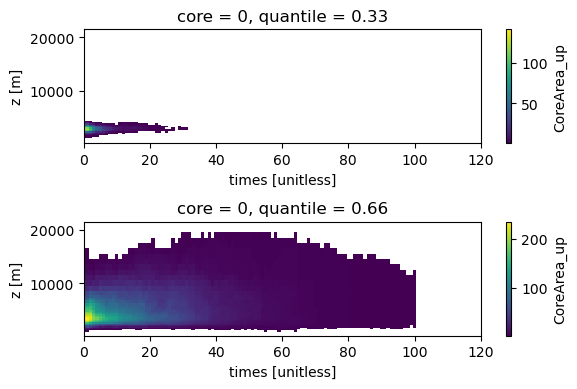

In [49]:
fig, axes = plt.subplots(2, 1, dpi=100)
nsample_CoreArea_up_shallow_d2.transpose().plot(ax=axes[0])
nsample_CoreArea_up_deep_d2.transpose().plot(ax=axes[1])
axes[0].set_xlim(0,120)
axes[1].set_xlim(0,120)
fig.tight_layout()

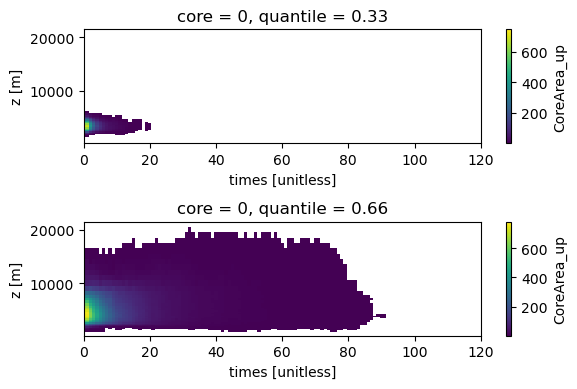

In [50]:
fig, axes = plt.subplots(2, 1, dpi=100)
nsample_CoreArea_up_shallow_d3.transpose().plot(ax=axes[0])
nsample_CoreArea_up_deep_d3.transpose().plot(ax=axes[1])
axes[0].set_xlim(0,120)
axes[1].set_xlim(0,120)
fig.tight_layout()

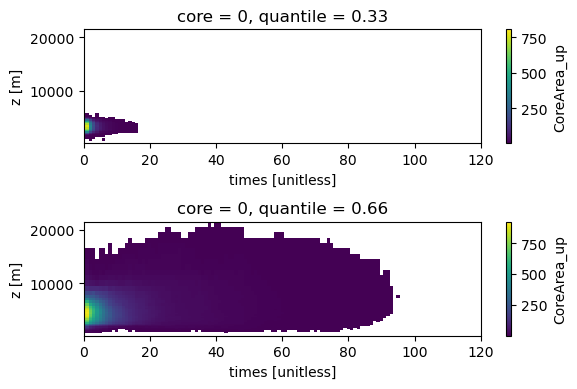

In [51]:
fig, axes = plt.subplots(2, 1, dpi=100)
nsample_CoreArea_up_shallow_d4.transpose().plot(ax=axes[0])
nsample_CoreArea_up_deep_d4.transpose().plot(ax=axes[1])
axes[0].set_xlim(0,120)
axes[1].set_xlim(0,120)
fig.tight_layout()

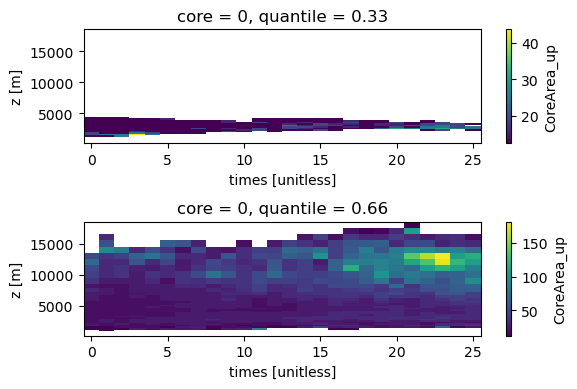

In [52]:
fig, axes = plt.subplots(2, 1, dpi=100)
CoreArea_up_shallow_d2.median(dim='tracks').transpose().sel(times=slice(0,25), z=slice(0,18000)).plot(ax=axes[0])
CoreArea_up_deep_d2.median(dim='tracks').transpose().sel(times=slice(0,25), z=slice(0,18000)).plot(ax=axes[1])
fig.tight_layout()

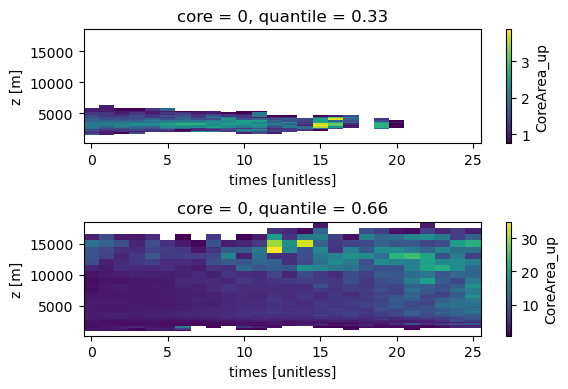

In [53]:
fig, axes = plt.subplots(2, 1, dpi=100)
CoreArea_up_shallow_d3.median(dim='tracks').transpose().sel(times=slice(0,25), z=slice(0,18000)).plot(ax=axes[0])
CoreArea_up_deep_d3.median(dim='tracks').transpose().sel(times=slice(0,25), z=slice(0,18000)).plot(ax=axes[1])
fig.tight_layout()

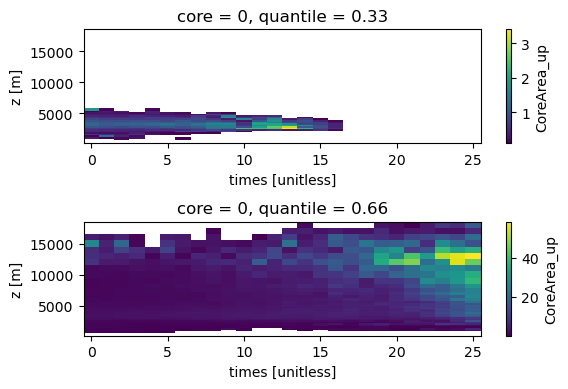

In [54]:
fig, axes = plt.subplots(2, 1, dpi=100)
CoreArea_up_shallow_d4.median(dim='tracks').transpose().sel(times=slice(0,25), z=slice(0,18000)).plot(ax=axes[0])
CoreArea_up_deep_d4.median(dim='tracks').transpose().sel(times=slice(0,25), z=slice(0,18000)).plot(ax=axes[1])
fig.tight_layout()

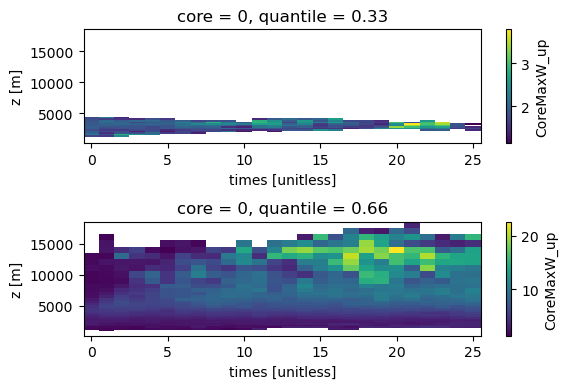

In [55]:
fig, axes = plt.subplots(2, 1, dpi=100)
CoreMaxW_up_shallow_d2.median(dim='tracks').transpose().sel(times=slice(0,25), z=slice(0,18000)).plot(ax=axes[0])
CoreMaxW_up_deep_d2.median(dim='tracks').transpose().sel(times=slice(0,25), z=slice(0,18000)).plot(ax=axes[1])
fig.tight_layout()

In [56]:
# plot individual tracks to check issues, particularly shallow ones

In [57]:
# maxETH_10dbz_
# dss_deep_d2.muc.plot.hist()

In [58]:
# Time for representative environment
time_env = -3

# Convert HAMSL to AGL, then select a representative time before CI
LCL_mu_deep_d2 = (dss_deep_d2['LCL_height_mu'] + dss_deep_d2['Z_surface']).sel(times=time_env) / 1000.
LCL_mu_shallow_d2 = (dss_shallow_d2['LCL_height_mu'] + dss_shallow_d2['Z_surface']).sel(times=time_env) / 1000.
LFC_mu_deep_d2 = (dss_deep_d2['LFC_height_mu'] + dss_deep_d2['Z_surface']).sel(times=time_env) / 1000.
LFC_mu_shallow_d2 = (dss_shallow_d2['LFC_height_mu'] + dss_shallow_d2['Z_surface']).sel(times=time_env) / 1000.

(array([  4.,  67., 130., 144.,  82.,  57.,  22.,   9.,   0.,   2.]),
 array([0.6841069, 1.2087992, 1.7334917, 2.258184 , 2.7828765, 3.3075688,
        3.832261 , 4.3569536, 4.881646 , 5.406338 , 5.9310308],
       dtype=float32),
 <BarContainer object of 10 artists>)

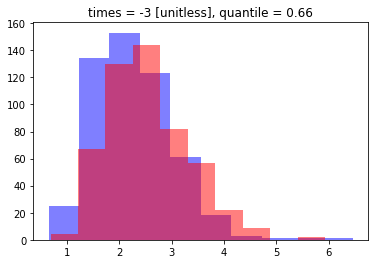

In [59]:
LCL_mu_deep_d2.plot.hist(color='b', alpha=0.5)
LFC_mu_deep_d2.plot.hist(color='r', alpha=0.5)

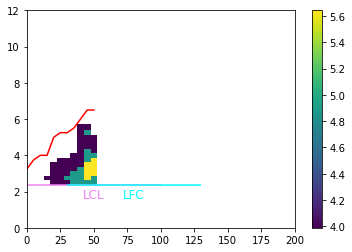

In [60]:
itrack = 2
plt.pcolormesh(xtime, height, 2*np.sqrt(CoreArea_up_deep_d2.isel(tracks=itrack).transpose()/np.pi), shading='nearest')
plt.plot(xtime, maxETH_10dbz_deep_d2.isel(tracks=itrack), color='r')
line_length = 100
LCL_t0 = 0
LCL_t1 = LCL_t0 + line_length
LFC_t0 = 30
LFC_t1 = LFC_t0 + line_length
plt.hlines(y=LCL_mu_deep_d2.isel(tracks=itrack), xmin=LCL_t0, xmax=LCL_t1, color='violet')
plt.hlines(y=LFC_mu_deep_d2.isel(tracks=itrack), xmin=LFC_t0, xmax=LFC_t1, color='cyan')
LCL_text_x = LCL_t0 + line_length / 2
LCL_text_y = LCL_mu_deep_d2.isel(tracks=itrack)-0.2
LFC_text_x = LFC_t0 + line_length / 2
LFC_text_y = LFC_mu_deep_d2.isel(tracks=itrack)-0.2
plt.text(LCL_text_x, LCL_text_y, 'LCL', ha='center', va='top', color='violet', fontsize=12)
plt.text(LFC_text_x, LFC_text_y, 'LFC', ha='center', va='top', color='cyan', fontsize=12)
plt.xlim(0,200)
plt.ylim(0,12)
plt.colorbar()

In [61]:
# Get updraft track coordinates
c_times = CoreMaxW_up_deep_d2.coords['times'].data
c_z = CoreMaxW_up_deep_d2.coords['z'].data

# Define a time window to sample updraft
time_start = 0  # [min]
time_end = 60  # [min]
# tidx_start = int(time_start / time_res)
# tidx_end = int(time_end / time_res)
tidx_start = np.where(xtime == time_start)[0].item()
tidx_end = np.where(xtime == time_end)[0].item()
print(tidx_start, tidx_end)

12 24


In [62]:
xtime.data[tidx_start], xtime.data[tidx_end]

(0.0, 60.0)

In [63]:
CoreArea_up_deep_d2.shape, CoreMaxW_up_deep_d2.shape, maxETH_10dbz_deep_d2.shape

((520, 212, 40), (520, 212, 40), (520, 212))

## Make 2D updraft object masks for each track 

In [64]:
def get_W_properties(W_binary):
    """
    Get W object properties given a 2D binary array
    
    Args:
        W_binary: np.array [times, height]
            Binary array.
            
    Returns:
        out_dict: dictionary
            A dictionary containing W object property variables.    
    """
    
    # Label the connected pixels
    label_image, n_obj = label(W_binary > 0)
    # Trim the times, then get the unique values of the labeled image, and the pixel counts
    label_num_, npix_ = np.unique(label_image[tidx_start:tidx_end,:], return_counts=True)
    # Trim the 0 (not an object), then count the number of W objects
    label_num_W = np.trim_zeros(label_num_)
    n_obj_W = len(label_num_W)

    # Make output arrays
    mask_time2d = np.zeros(label_image.shape)
    mask_small = np.full(label_image.shape, np.NaN)
    mask_small_plt = np.full(label_image.shape, np.NaN)
    max_indices_z = np.full(label_image.shape, -1, dtype=int)
    mask_top = np.full(label_image.shape[0], np.NaN)
    mask_base = np.full(label_image.shape[0], np.NaN)
    Wtime_start = np.NaN
    Wtime_end = np.NaN
    Wlifetime = np.NaN

    # Get the size (pixel count) of the W objects
    if n_obj_W > 0:
        # Exclude the first value (0)
        npix_W = npix_[1:]
        # Get the largest object number
        big_cell = label_num_W[np.argmax(npix_W)]

        # Mask time period to keep object    
        mask_time2d[tidx_start:tidx_end+1,:] = 1
        # Make a binary mask of the largest object
        mask_small[(label_image==big_cell) & (mask_time2d==1)] = 1
        # Make a mask for small objects
        mask_small_plt[(mask_small != 1) & (W_binary > 0)] = 1

        #------------------------------------
        # Get updraft top heights
        # Get indices of the last occurrence of the max value along the y-axis (height)
        max_indices_z = np.argmax(mask_small[:,::-1]==1, axis=1)
        # Invert the indices to get the correct position along the original y-axis
        max_indices_z = mask_small.shape[1] - 1 - max_indices_z
        # Filter out indices where the mask is False
        max_indices_z[np.isnan(np.nanmax(mask_small, axis=1))] = -1
        # Apply indices to height array using advanced indexing
        mask_top = height.data[max_indices_z]
        # Replace times when indices is invalid with NaN (< 0)
        mask_top[max_indices_z < 0] = np.NaN
        #------------------------------------
        #------------------------------------
        # Get updraft base heights
        # Get indices of the last occurrence of the max value along the y-axis (height)
        min_indices_z = np.argmax(mask_small==1, axis=1)
        # Filter out indices where the mask is False
        min_indices_z[np.isnan(np.nanmax(mask_small, axis=1))] = -1
        # Apply indices to height array using advanced indexing
        mask_base = height.data[min_indices_z]
        # Replace times when indices is invalid with NaN (< 0)
        mask_base[min_indices_z < 0] = np.NaN
        #------------------------------------

        # Find start/end time indices of the largest object
        tind, zind = np.where(label_image==big_cell)
        istart, iend = min(tind), max(tind)
        # Mark start/end time and lifetime
        Wtime_start = xtime[istart]
        Wtime_end = xtime[iend]
        Wlifetime = (iend - istart + 1) * time_res

    # Put outputs to a dictionary
    out_dict = {
        'mask_small': mask_small,
        'mask_small_plt': mask_small_plt,
        'mask_top': mask_top,
        'mask_base': mask_base,
        'Wtime_start': Wtime_start,
        'Wtime_end': Wtime_end,
        'Wlifetime': Wlifetime,
    }
        
    return out_dict

In [65]:
def make_W_mask(da_W):
    """
    Make W object masks for all tracks
    
    Args:
        da_W: DataArray [tracks, times, height]
            Data array containing W.
            
    Returns:
        out_dict: dictionary
            A dictionary containing W object property variables.    
    """

    # Make a binary array for W
    binary_w = np.zeros_like(da_W)
    binary_w[da_W > 0] = 1
    
    # Make output arrays
    _ntracks = da_W.sizes['tracks']
    _ntimes = da_W.sizes['times']
    Wmask = np.full(da_W.shape, np.NaN)
    Wmask_plt = np.full(da_W.shape, np.NaN)
    Wtime_start = np.full(_ntracks, np.NaN)
    Wtime_end = np.full(_ntracks, np.NaN)
    Wlifetime = np.full(_ntracks, np.NaN)
    Wtop = np.full((_ntracks, _ntimes), np.NaN)
    Wbase = np.full((_ntracks, _ntimes), np.NaN)

    # Loop over each track
    for itrack in range(0, _ntracks):
        # Get the binary mask for this track
        iW_binary = binary_w[itrack,:,:].squeeze()
        # Call function to get W object properties
        iW_object_dict = get_W_properties(iW_binary)
        
        # Save values to output arrays
        Wmask[itrack,:,:] = iW_object_dict['mask_small']
        Wmask_plt[itrack,:,:] = iW_object_dict['mask_small_plt']
        Wtop[itrack,:] = iW_object_dict['mask_top']
        Wbase[itrack,:] = iW_object_dict['mask_base']
        Wtime_start[itrack] = iW_object_dict['Wtime_start']
        Wtime_end[itrack] = iW_object_dict['Wtime_end']
        Wlifetime[itrack] = iW_object_dict['Wlifetime']    

    # Convert to DataArrays
    Wmask = xr.DataArray(Wmask, coords=da_W.coords, dims=('tracks','times','z'))
    Wmask_plt = xr.DataArray(Wmask_plt, coords=da_W.coords, dims=('tracks','times','z'))
    Wtop = xr.DataArray(Wtop, coords={'tracks':da_W.coords['tracks'], 'times':da_W.coords['times']}, dims=('tracks','times'))
    Wbase = xr.DataArray(Wbase, coords={'tracks':da_W.coords['tracks'], 'times':da_W.coords['times']}, dims=('tracks','times'))
    Wtime_start = xr.DataArray(Wtime_start, coords={'tracks':da_W.coords['tracks']}, dims=('tracks'))
    Wtime_end = xr.DataArray(Wtime_end, coords={'tracks':da_W.coords['tracks']}, dims=('tracks'))
    Wlifetime = xr.DataArray(Wlifetime, coords={'tracks':da_W.coords['tracks']}, dims=('tracks'))
    # Put outputs in a dictionary
    out_dict = {
        'Wmask': Wmask,
        'Wmask_plt': Wmask_plt,
        'Wtop': Wtop,
        'Wbase': Wbase,
        'Wtime_start': Wtime_start,
        'Wtime_end': Wtime_end,
        'Wlifetime': Wlifetime,        
    }
    return out_dict

In [66]:
Wmask_dict_deep_d2 = make_W_mask(CoreArea_up_deep_d2)
Wmask_dict_shallow_d2 = make_W_mask(CoreArea_up_shallow_d2)

/tmp/ipykernel_38353/4093692548.py:54: RuntimeWarning: All-NaN slice encountered
  max_indices_z[np.isnan(np.nanmax(mask_small, axis=1))] = -1
/tmp/ipykernel_38353/4093692548.py:65: RuntimeWarning: All-NaN slice encountered
  min_indices_z[np.isnan(np.nanmax(mask_small, axis=1))] = -1


In [67]:
Wmask_dict_deep_d3 = make_W_mask(CoreArea_up_deep_d3)
Wmask_dict_shallow_d3 = make_W_mask(CoreArea_up_shallow_d3)

/tmp/ipykernel_38353/4093692548.py:54: RuntimeWarning: All-NaN slice encountered
  max_indices_z[np.isnan(np.nanmax(mask_small, axis=1))] = -1
/tmp/ipykernel_38353/4093692548.py:65: RuntimeWarning: All-NaN slice encountered
  min_indices_z[np.isnan(np.nanmax(mask_small, axis=1))] = -1


In [68]:
Wmask_dict_deep_d4 = make_W_mask(CoreArea_up_deep_d4)
Wmask_dict_shallow_d4 = make_W_mask(CoreArea_up_shallow_d4)

/tmp/ipykernel_38353/4093692548.py:54: RuntimeWarning: All-NaN slice encountered
  max_indices_z[np.isnan(np.nanmax(mask_small, axis=1))] = -1
/tmp/ipykernel_38353/4093692548.py:65: RuntimeWarning: All-NaN slice encountered
  min_indices_z[np.isnan(np.nanmax(mask_small, axis=1))] = -1


In [69]:
# Wmask_dict_deep_d2['Wlifetime'].sizes['tracks']

In [70]:
# CoreArea_up_shallow_d2.isel(times=slice(tidx_start,tidx_end)).plot.hist()

(array([ 0., 31., 57., 64., 34., 24., 28., 27., 17., 11., 11., 15.,  6.,
         7.,  9.,  7.,  2.,  4.,  3.,  8., 10.,  1.,  3.,  4.,  1.,  4.,
         3.,  2.,  5.,  4.,  3.,  3.,  2.,  4.,  2.,  1.,  3.,  2.,  3.,
         1.,  0.,  2.,  1.,  0.,  1.,  0.,  1.,  0.,  1.,  3.,  1.,  0.,
         0.,  1.,  4.,  1.,  0.,  0.,  1.]),
 array([  0,   5,  10,  15,  20,  25,  30,  35,  40,  45,  50,  55,  60,
         65,  70,  75,  80,  85,  90,  95, 100, 105, 110, 115, 120, 125,
        130, 135, 140, 145, 150, 155, 160, 165, 170, 175, 180, 185, 190,
        195, 200, 205, 210, 215, 220, 225, 230, 235, 240, 245, 250, 255,
        260, 265, 270, 275, 280, 285, 290, 295]),
 <BarContainer object of 59 artists>)

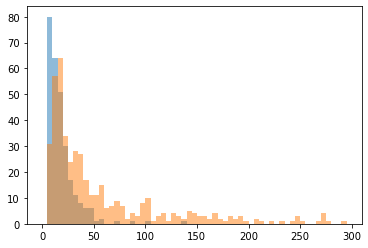

In [71]:
bins = np.arange(0, 300, 5)
plt.hist(Wmask_dict_shallow_d2['Wlifetime'], bins=bins, alpha=0.5, label='D2 shallow')
plt.hist(Wmask_dict_deep_d2['Wlifetime'], bins=bins, alpha=0.5, label='D2 deep')

(array([  0.,  25., 155., 107.,  96.,  78.,  67.,  57.,  39.,  39.,  39.,
         25.,  20.,  16.,  12.,  14.,  15.,  10.,   4.,  12.,  11.,  11.,
          1.,   4.,   7.,   4.,   3.,   4.,   2.,   0.,   3.,   1.,   4.,
          0.,   3.,   2.,   0.,   1.,   0.,   0.,   0.,   1.,   1.,   1.,
          2.,   0.,   0.,   0.,   2.,   1.,   1.,   0.,   0.,   0.,   0.,
          0.,   1.,   1.,   0.]),
 array([  0,   5,  10,  15,  20,  25,  30,  35,  40,  45,  50,  55,  60,
         65,  70,  75,  80,  85,  90,  95, 100, 105, 110, 115, 120, 125,
        130, 135, 140, 145, 150, 155, 160, 165, 170, 175, 180, 185, 190,
        195, 200, 205, 210, 215, 220, 225, 230, 235, 240, 245, 250, 255,
        260, 265, 270, 275, 280, 285, 290, 295]),
 <BarContainer object of 59 artists>)

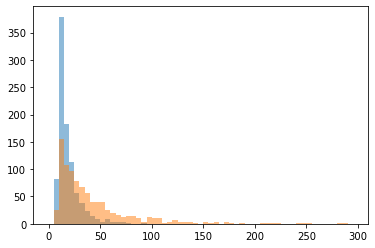

In [72]:
bins = np.arange(0, 300, 5)
plt.hist(Wmask_dict_shallow_d3['Wlifetime'], bins=bins, alpha=0.5, label='D2 shallow')
plt.hist(Wmask_dict_deep_d3['Wlifetime'], bins=bins, alpha=0.5, label='D2 deep')

(array([  0.,  22., 209., 139., 111.,  86.,  74.,  64.,  53.,  50.,  31.,
         17.,  21.,  18.,  19.,  14.,   9.,  11.,   5.,   5.,   8.,   6.,
          7.,   5.,   7.,   3.,   2.,   3.,   3.,   0.,   3.,   0.,   1.,
          0.,   0.,   1.,   1.,   0.,   4.,   0.,   1.,   2.,   2.,   0.,
          0.,   2.,   0.,   0.,   0.,   2.,   1.,   1.,   1.,   1.,   0.,
          0.,   0.,   0.,   2.]),
 array([  0,   5,  10,  15,  20,  25,  30,  35,  40,  45,  50,  55,  60,
         65,  70,  75,  80,  85,  90,  95, 100, 105, 110, 115, 120, 125,
        130, 135, 140, 145, 150, 155, 160, 165, 170, 175, 180, 185, 190,
        195, 200, 205, 210, 215, 220, 225, 230, 235, 240, 245, 250, 255,
        260, 265, 270, 275, 280, 285, 290, 295]),
 <BarContainer object of 59 artists>)

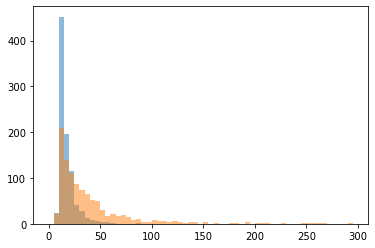

In [73]:
bins = np.arange(0, 300, 5)
plt.hist(Wmask_dict_shallow_d4['Wlifetime'], bins=bins, alpha=0.5, label='D2 shallow')
plt.hist(Wmask_dict_deep_d4['Wlifetime'], bins=bins, alpha=0.5, label='D2 deep')

## Subset tracks based on W statistics

In [74]:
# nsample_CoreArea_up_shallow_d2.shape, CoreMaxW_up_shallow_d2.shape
# track_lifetime_range

In [75]:
# # Convert track_lifetime_range to time indices
# track_duration_range = (np.array(track_lifetime_range) / time_res).astype(int)
# track_duration_range

In [76]:
# Find track indices where updraft objects exist (Wmask lifetime > 0)
Wid_shallow_d2 = (Wmask_dict_shallow_d2['Wlifetime'] > 0)
Wid_deep_d2 = (Wmask_dict_deep_d2['Wlifetime'] > 0)

# Subset shallow/deep DataSets using the track indices
dss_shallow_d2sub = dss_shallow_d2.sel(tracks=Wid_shallow_d2)
dss_deep_d2sub = dss_deep_d2.sel(tracks=Wid_deep_d2)

ntracks_shallow_d2sub = dss_shallow_d2sub.sizes['tracks']
print(f'D2 number of shallow tracks: {ntracks_shallow_d2sub}')
print(f'Deep tracks will be further filtered below.')

# Subset these variables as they are already loaded in memory
CoreMaxW_up_shallow_d2sub = CoreMaxW_up_shallow_d2.isel(tracks=Wid_shallow_d2)
CoreArea_up_shallow_d2sub = CoreArea_up_shallow_d2.isel(tracks=Wid_shallow_d2)
maxETH_10dbz_shallow_d2sub = maxETH_10dbz_shallow_d2.isel(tracks=Wid_shallow_d2)

CoreMaxW_up_deep_d2sub = CoreMaxW_up_deep_d2.isel(tracks=Wid_deep_d2)
CoreArea_up_deep_d2sub = CoreArea_up_deep_d2.isel(tracks=Wid_deep_d2)
maxETH_10dbz_deep_d2sub = maxETH_10dbz_deep_d2.isel(tracks=Wid_deep_d2)

# Subset tracks for the W mask dictionary
Wmask_dict_shallow_d2sub = {}
Wmask_dict_deep_d2sub = {}
for key, var in Wmask_dict_shallow_d2.items():
    Wmask_dict_shallow_d2sub[key] = Wmask_dict_shallow_d2[key].isel(tracks=Wid_shallow_d2)
    Wmask_dict_deep_d2sub[key] = Wmask_dict_deep_d2[key].isel(tracks=Wid_deep_d2)

D2 number of shallow tracks: 280
Deep tracks will be further filtered below.


In [77]:
# Find track indices where updraft objects exist (Wmask lifetime > 0)
Wid_shallow_d3 = (Wmask_dict_shallow_d3['Wlifetime'] > 0)
Wid_deep_d3 = (Wmask_dict_deep_d3['Wlifetime'] > 0)

# Subset shallow/deep DataSets using the track indices
dss_shallow_d3sub = dss_shallow_d3.sel(tracks=Wid_shallow_d3)
dss_deep_d3sub = dss_deep_d3.sel(tracks=Wid_deep_d3)

ntracks_shallow_d3sub = dss_shallow_d3sub.sizes['tracks']
print(f'D3 number of shallow tracks: {ntracks_shallow_d3sub}')
print(f'Deep tracks will be further filtered below.')

# Subset these variables as they are already loaded in memory
CoreMaxW_up_shallow_d3sub = CoreMaxW_up_shallow_d3.isel(tracks=Wid_shallow_d3)
CoreArea_up_shallow_d3sub = CoreArea_up_shallow_d3.isel(tracks=Wid_shallow_d3)
maxETH_10dbz_shallow_d3sub = maxETH_10dbz_shallow_d3.isel(tracks=Wid_shallow_d3)

CoreMaxW_up_deep_d3sub = CoreMaxW_up_deep_d3.isel(tracks=Wid_deep_d3)
CoreArea_up_deep_d3sub = CoreArea_up_deep_d3.isel(tracks=Wid_deep_d3)
maxETH_10dbz_deep_d3sub = maxETH_10dbz_deep_d3.isel(tracks=Wid_deep_d3)

# Subset tracks for the W mask dictionary
Wmask_dict_shallow_d3sub = {}
Wmask_dict_deep_d3sub = {}
for key, var in Wmask_dict_shallow_d3.items():
    Wmask_dict_shallow_d3sub[key] = Wmask_dict_shallow_d3[key].isel(tracks=Wid_shallow_d3)
    Wmask_dict_deep_d3sub[key] = Wmask_dict_deep_d3[key].isel(tracks=Wid_deep_d3)

D3 number of shallow tracks: 921
Deep tracks will be further filtered below.


In [78]:
# Find track indices where updraft objects exist (Wmask lifetime > 0)
Wid_shallow_d4 = (Wmask_dict_shallow_d4['Wlifetime'] > 0)
Wid_deep_d4 = (Wmask_dict_deep_d4['Wlifetime'] > 0)

# Subset shallow/deep DataSets using the track indices
dss_shallow_d4sub = dss_shallow_d4.sel(tracks=Wid_shallow_d4)
dss_deep_d4sub = dss_deep_d4.sel(tracks=Wid_deep_d4)

ntracks_shallow_d4sub = dss_shallow_d4sub.sizes['tracks']
print(f'D4 number of shallow tracks: {ntracks_shallow_d4sub}')
print(f'Deep tracks will be further filtered below.')

# Subset these variables as they are already loaded in memory
CoreMaxW_up_shallow_d4sub = CoreMaxW_up_shallow_d4.isel(tracks=Wid_shallow_d4)
CoreArea_up_shallow_d4sub = CoreArea_up_shallow_d4.isel(tracks=Wid_shallow_d4)
maxETH_10dbz_shallow_d4sub = maxETH_10dbz_shallow_d4.isel(tracks=Wid_shallow_d4)

CoreMaxW_up_deep_d4sub = CoreMaxW_up_deep_d4.isel(tracks=Wid_deep_d4)
CoreArea_up_deep_d4sub = CoreArea_up_deep_d4.isel(tracks=Wid_deep_d4)
maxETH_10dbz_deep_d4sub = maxETH_10dbz_deep_d4.isel(tracks=Wid_deep_d4)

# Subset tracks for the W mask dictionary
Wmask_dict_shallow_d4sub = {}
Wmask_dict_deep_d4sub = {}
for key, var in Wmask_dict_shallow_d4.items():
    Wmask_dict_shallow_d4sub[key] = Wmask_dict_shallow_d4[key].isel(tracks=Wid_shallow_d4)
    Wmask_dict_deep_d4sub[key] = Wmask_dict_deep_d4[key].isel(tracks=Wid_deep_d4)

D4 number of shallow tracks: 894
Deep tracks will be further filtered below.


## Get preCI environmental variables: LCL, LFC

In [79]:
# Time for representative environment [time indices]
time_env = -3

# Convert HAMSL to AGL, then select a representative time before CI
LCL_mu_shallow_d2sub = (dss_shallow_d2sub['LCL_height_mu'] + dss_shallow_d2sub['Z_surface']).sel(times=time_env) / 1000.
LCL_mu_deep_d2sub = (dss_deep_d2sub['LCL_height_mu'] + dss_deep_d2sub['Z_surface']).sel(times=time_env) / 1000.
LFC_mu_shallow_d2sub = (dss_shallow_d2sub['LFC_height_mu'] + dss_shallow_d2sub['Z_surface']).sel(times=time_env) / 1000.
LFC_mu_deep_d2sub = (dss_deep_d2sub['LFC_height_mu'] + dss_deep_d2sub['Z_surface']).sel(times=time_env) / 1000.

In [80]:
# Convert HAMSL to AGL, then select a representative time before CI
LCL_mu_shallow_d3sub = (dss_shallow_d3sub['LCL_height_mu'] + dss_shallow_d3sub['Z_surface']).sel(times=time_env) / 1000.
LCL_mu_deep_d3sub = (dss_deep_d3sub['LCL_height_mu'] + dss_deep_d3sub['Z_surface']).sel(times=time_env) / 1000.
LFC_mu_shallow_d3sub = (dss_shallow_d3sub['LFC_height_mu'] + dss_shallow_d3sub['Z_surface']).sel(times=time_env) / 1000.
LFC_mu_deep_d3sub = (dss_deep_d3sub['LFC_height_mu'] + dss_deep_d3sub['Z_surface']).sel(times=time_env) / 1000.

In [81]:
# Convert HAMSL to AGL, then select a representative time before CI
LCL_mu_shallow_d4sub = (dss_shallow_d4sub['LCL_height_mu'] + dss_shallow_d4sub['Z_surface']).sel(times=time_env) / 1000.
LCL_mu_deep_d4sub = (dss_deep_d4sub['LCL_height_mu'] + dss_deep_d4sub['Z_surface']).sel(times=time_env) / 1000.
LFC_mu_shallow_d4sub = (dss_shallow_d4sub['LFC_height_mu'] + dss_shallow_d4sub['Z_surface']).sel(times=time_env) / 1000.
LFC_mu_deep_d4sub = (dss_deep_d4sub['LFC_height_mu'] + dss_deep_d4sub['Z_surface']).sel(times=time_env) / 1000.

## Function to fit a linear line for cloud-top height within a time period

In [82]:
def fit_linear(xtime, Wtop, tidx_end, min_nsample=3):
    """
    Perform linear fit to a 1D time series array
    
    Args:
        xtime: np.array
            Array containing time values
        Wtop: np.array
            Array containing values to be fitted
        tidx_end: int
            Max time index to subset the time series before fitting
        min_nsample: int
            Minimum number of valid samples for fitting
            
    Returns:
        out_dict: dictionary
            A dictionary containing W object property variables.    
    """
    # Set default values
    slope, intercept, r_value, p_value, std_err = np.NaN, np.NaN, np.NaN, np.NaN, np.NaN
    nt = len(xtime)
    predicted_x = np.full(nt, np.NaN, dtype=np.float32)
    predicted_y = np.full(nt, np.NaN, dtype=np.float32)
    
    # Find time index for max Wtop within the subet time period
    _Wtop_max_tidx = Wtop[0:tidx_end+1].argmax().item()

    # Subset times to Wtop max
    _xtime = xtime.data[0:_Wtop_max_tidx+1]
    _Wtop = Wtop.data[0:_Wtop_max_tidx+1]
    
    # Find valid value time indices
    tidx_valid = _Wtop > 0
    n_valid = np.count_nonzero(tidx_valid)
    # print(n_valid)
    if (n_valid >= min_nsample):
        _xtime = _xtime[tidx_valid]
        _Wtop = _Wtop[tidx_valid]

        # Perform linear regression
        slope, intercept, r_value, p_value, std_err = linregress(_xtime, _Wtop)
        
        # Find indices matching the subsetted time to the full time
        t_idx = np.where(np.isin(xtime, _xtime))[0]
        # Save the valid subsetted time
        predicted_x[t_idx] = _xtime
        # Predict y values using the linear fit
        predicted_y[t_idx] = slope * _xtime + intercept
        
    # Put output values in a dictionary
    out_dict = {
        'slope': slope,
        'intercept': intercept,
        'r_value': r_value,
        'p_value': p_value,
        'std_err': std_err,
        'predicted_x': predicted_x,
        'predicted_y': predicted_y,
    }
    return out_dict

In [83]:
# _Wtop = Wmask_dict_deep_d2sub['Wtop'].isel(tracks=338)
# fit_dict = fit_linear(xtime, _Wtop, tidx_end, min_nsample=3)

# Minimum number of sample to fit updraft top height
min_nsample_fit = 3

In [84]:
# Make arrays to store data
ntracks_deep_d2sub = Wmask_dict_deep_d2sub['Wtop'].sizes['tracks']
Wtop_slope_deep_d2sub = np.full(ntracks_deep_d2sub, np.NaN, dtype=np.float32)
Wtop_fit_deep_d2sub = np.full((ntracks_deep_d2sub, ntimes), np.NaN, dtype=np.float32)

# Loop over each track
for itrack in range(ntracks_deep_d2sub):
    _Wtop = Wmask_dict_deep_d2sub['Wtop'].isel(tracks=itrack)
    fit_dict = fit_linear(xtime, _Wtop, tidx_end, min_nsample=min_nsample_fit)
    Wtop_slope_deep_d2sub[itrack] = fit_dict['slope']
    Wtop_fit_deep_d2sub[itrack,:] = fit_dict['predicted_y']

In [85]:
# Make arrays to store data
ntracks_deep_d3sub = Wmask_dict_deep_d3sub['Wtop'].sizes['tracks']
Wtop_slope_deep_d3sub = np.full(ntracks_deep_d3sub, np.NaN, dtype=np.float32)
Wtop_fit_deep_d3sub = np.full((ntracks_deep_d3sub, ntimes), np.NaN, dtype=np.float32)

# Loop over each track
for itrack in range(ntracks_deep_d3sub):
    _Wtop = Wmask_dict_deep_d3sub['Wtop'].isel(tracks=itrack)
    fit_dict = fit_linear(xtime, _Wtop, tidx_end, min_nsample=min_nsample_fit)
    Wtop_slope_deep_d3sub[itrack] = fit_dict['slope']
    Wtop_fit_deep_d3sub[itrack,:] = fit_dict['predicted_y']

In [86]:
# Make arrays to store data
ntracks_deep_d4sub = Wmask_dict_deep_d4sub['Wtop'].sizes['tracks']
Wtop_slope_deep_d4sub = np.full(ntracks_deep_d4sub, np.NaN, dtype=np.float32)
Wtop_fit_deep_d4sub = np.full((ntracks_deep_d4sub, ntimes), np.NaN, dtype=np.float32)

# Loop over each track
for itrack in range(ntracks_deep_d4sub):
    _Wtop = Wmask_dict_deep_d4sub['Wtop'].isel(tracks=itrack)
    fit_dict = fit_linear(xtime, _Wtop, tidx_end, min_nsample=min_nsample_fit)
    Wtop_slope_deep_d4sub[itrack] = fit_dict['slope']
    Wtop_fit_deep_d4sub[itrack,:] = fit_dict['predicted_y']

In [87]:
# itrack = 241
# _Wtop = Wmask_dict_deep_d2sub['Wtop'].isel(tracks=itrack)
# _Wtop_max_tidx = _Wtop[0:tidx_end+1].argmax().item()
# xtime.data[_Wtop_max_tidx]
# plt.plot(xtime, _Wtop)
# plt.plot(xtime, Wtop_fit_deep_d2sub[itrack,:], ls='--')

In [88]:
print(_Wtop)

<xarray.DataArray (times: 212)>
array([ nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan, 4.25, 4.  , 4.5 , 5.5 , 6.5 ,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan, 

## Find deep cell tracks with positive updraft top slope, and updraft base close to LCL
## These are the track to keep in the analysis

In [89]:
Wmask_dict_deep_d2sub['Wbase'].shape, LCL_mu_deep_d2sub.shape, Wtop_slope_deep_d2sub.shape, ntracks_deep_d2sub

((448, 212), (448,), (448,), 448)

In [90]:
# Threshold for max distance between updraft base and LCL height
max_Wbase_LCL_dist = 2.0
# Threshold for updraft top fit line slope
min_Wtop_slope = 0

In [91]:
# Calculate distance between minimum updraft base height and MU LCL height (HAMSL)
Wbase_LCL_diff_d2sub = np.absolute(Wmask_dict_deep_d2sub['Wbase'].min(dim='times') - LCL_mu_deep_d2sub)

# # TODO: potentially could also use updraft top height and ETH difference as further constrain
# # But need to constrain periods for the updraft top rather than over the entire cell duration
# Wtop_ETH_diff_d2sub = np.absolute(Wmask_dict_deep_d2sub['Wtop'] - maxETH_10dbz_deep_d2sub)

# True/False flag for positive slope
Wtop_Pslope_deep_d2sub = Wtop_slope_deep_d2sub > min_Wtop_slope
# True/False flag for updraft base height from LCL
Wbase_LCL_deep_d2sub = Wbase_LCL_diff_d2sub <= max_Wbase_LCL_dist
# Both positive slope & updraft base flag
Wkeep_flag_d2sub = (Wtop_Pslope_deep_d2sub & Wbase_LCL_deep_d2sub).compute()
# Track indicies to keep
# Wid_keep_deep_d2sub = np.where(Wtop_Pslope_deep_d2sub)[0]
Wid_keep_deep_d2sub = np.where(Wkeep_flag_d2sub)[0]

ntracksW_deep_d2 = len(Wid_keep_deep_d2sub)
ntracksW_shallow_d2 = len(Wid_shallow_d2)
print(f'D2 number of deep tracks to keep: {ntracksW_deep_d2}, fraction to all deep tracks: {100*(ntracksW_deep_d2 / ntracks_deep_d2sub):.1f}%')
print(f'D2 number of shallow tracks to keep: {ntracksW_shallow_d2}')

D2 number of deep tracks to keep: 276, fraction to all deep tracks: 61.6%
D2 number of shallow tracks to keep: 443


In [92]:
# Calculate distance between minimum updraft base height and MU LCL height (HAMSL)
Wbase_LCL_diff_d3sub = np.absolute(Wmask_dict_deep_d3sub['Wbase'].min(dim='times') - LCL_mu_deep_d3sub)

# # TODO: potentially could also use updraft top height and ETH difference as further constrain
# # But need to constrain periods for the updraft top rather than over the entire cell duration
# Wtop_ETH_diff_d3sub = np.absolute(Wmask_dict_deep_d3sub['Wtop'] - maxETH_10dbz_deep_d3sub)

# True/False flag for positive slope
Wtop_Pslope_deep_d3sub = Wtop_slope_deep_d3sub > min_Wtop_slope
# True/False flag for updraft base height from LCL
Wbase_LCL_deep_d3sub = Wbase_LCL_diff_d3sub <= max_Wbase_LCL_dist
# Both positive slope & updraft base flag
Wkeep_flag_d3sub = (Wtop_Pslope_deep_d3sub & Wbase_LCL_deep_d3sub).compute()
# Track indicies to keep
# Wid_keep_deep_d3sub = np.where(Wtop_Pslope_deep_d3sub)[0]
Wid_keep_deep_d3sub = np.where(Wkeep_flag_d3sub)[0]

ntracksW_deep_d3 = len(Wid_keep_deep_d3sub)
ntracksW_shallow_d3 = len(Wid_shallow_d3)
print(f'D3 number of deep tracks to keep: {ntracksW_deep_d3}, fraction to all deep tracks: {100*(ntracksW_deep_d3 / ntracks_deep_d3sub):.1f}%')
print(f'D3 number of shallow tracks to keep: {ntracksW_shallow_d3}')

D3 number of deep tracks to keep: 494, fraction to all deep tracks: 54.5%
D3 number of shallow tracks to keep: 1003


In [93]:
# Calculate distance between minimum updraft base height and MU LCL height (HAMSL)
Wbase_LCL_diff_d4sub = np.absolute(Wmask_dict_deep_d4sub['Wbase'].min(dim='times') - LCL_mu_deep_d4sub)

# # TODO: potentially could also use updraft top height and ETH difference as further constrain
# # But need to constrain periods for the updraft top rather than over the entire cell duration
# Wtop_ETH_diff_d4sub = np.absolute(Wmask_dict_deep_d4sub['Wtop'] - maxETH_10dbz_deep_d4sub)

# True/False flag for positive slope
Wtop_Pslope_deep_d4sub = Wtop_slope_deep_d4sub > min_Wtop_slope
# True/False flag for updraft base height from LCL
Wbase_LCL_deep_d4sub = Wbase_LCL_diff_d4sub <= max_Wbase_LCL_dist
# Both positive slope & updraft base flag
Wkeep_flag_d4sub = (Wtop_Pslope_deep_d4sub & Wbase_LCL_deep_d4sub).compute()
# Track indicies to keep
# Wid_keep_deep_d4sub = np.where(Wtop_Pslope_deep_d4sub)[0]
Wid_keep_deep_d4sub = np.where(Wkeep_flag_d4sub)[0]

ntracksW_deep_d4 = len(Wid_keep_deep_d4sub)
ntracksW_shallow_d4 = len(Wid_shallow_d4)
print(f'D4 number of deep tracks to keep: {ntracksW_deep_d4}, fraction to all deep tracks: {100*(ntracksW_deep_d4 / ntracks_deep_d4sub):.1f}%')
print(f'D4 number of shallow tracks to keep: {ntracksW_shallow_d4}')

D4 number of deep tracks to keep: 495, fraction to all deep tracks: 47.9%
D4 number of shallow tracks to keep: 909


(array([ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  6.,  9., 15.,
        15.,  5., 23., 11., 24., 12., 12., 21., 13., 18.,  5.,  6., 17.,
         1.,  8.,  4.,  1., 10.,  4.,  7.,  2.,  3.,  7.,  1.,  2.,  1.,
         1.,  9.,  4.,  1.,  0.,  1.,  1.,  1.,  1.,  0.,  1.,  2.,  1.,
         2.,  0.,  1.,  1.,  2.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         1.,  0.,  0.,  0.]),
 array([-1.00000000e-01, -9.00000000e-02, -8.00000000e-02, -7.00000000e-02,
        -6.00000000e-02, -5.00000000e-02, -4.00000000e-02, -3.00000000e-02,
        -2.00000000e-02, -1.00000000e-02, -5.55111512e-17,  1.00000000e-02,
         2.00000000e-02,  3.00000000e-02,  4.00000000e-02,  5.00000000e-02,
         6.00000000e-02,  7.00000000e-02,  8.00000000e-02,  9.00000000e-02,
         1.00000000e-01,  1.10000000e-01,  1.20000000e-01,  1.30000000e-01,
         1.40000000e-01,  1.50000000e-01,  1.60000000e-01,  1.70000000e-01,
         1.80000000e-01,  1.90000000e-01,  2.00000000e-01,  2.10000000e-0

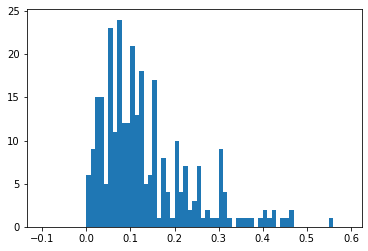

In [94]:
plt.hist(Wtop_slope_deep_d2sub, bins=np.arange(-0.1,0.6,0.01))

## Function to plot individual tracks of updrafts

In [95]:
def plot_tz_sample(xtime, height, da, da_mask, maxETH, cldTop, Wtime_startend, env_dict,
                   cldTop_fit=None, cldBase=None, keep_flag=None,
                   xlim=None, ylim=None, xlabel=None, ylabel=None, title=None, legend=None,
                   cmap=None, cblabels=None, fontsize=None, figsize=None, figname=None):
    
    mpl.rcParams['font.size'] = fontsize
    # mpl.rcParams['font.family'] = 'Helvetica'
    mpl.rcParams['font.family'] = 'DejaVu Sans'
    mpl.rcParams['figure.facecolor'] = 'white'

    fig = plt.figure(figsize=figsize, dpi=100)
    nrows = 1
    gs = gridspec.GridSpec(nrows, 2, height_ratios=np.repeat(1, nrows).tolist(), width_ratios=[1,0.04])
    gs.update(left=0.05, right=0.9, bottom=0.05, top=0.95, wspace=0.1, hspace=0.15)
    ax = plt.subplot(gs[0,0])
    cax = plt.subplot(gs[0,1])
    
    colors = {'ETH':'red', 'cldTop':'b', 'cldBase':'dodgerblue', 'LCL':'violet', 'LFC':'mediumorchid'}
    
    # Plot data
    pcm_da = ax.pcolormesh(xtime, height, da, shading='nearest', cmap=cmap)
    # Plot mask
    pcm_ma = ax.pcolormesh(xtime, height, da_mask, vmin=0., vmax=1, cmap='gray', alpha=0.8)
    # 
    ax.axvline(Wtime_startend['s'], lw=1, color='purple')
    ax.axvline(Wtime_startend['e'], lw=1, color='purple')
    ax.axvline(time_end, lw=1, ls=':', color='purple')
    # ETH line
    ETH_line = ax.plot(xtime, maxETH, color=colors['ETH'], label='10dBZ ETH')
    # cloud/updraft top line
    cldTop_line = ax.plot(xtime, cldTop, color=colors['cldTop'], label='Updraft Top')
    if cldBase is not None:
        cldBase_line = ax.plot(xtime, cldBase, color=colors['cldBase'], label='Updraft Base')
    # cloud/updraft top fit line
    if cldTop_fit is not None:
        cldTop_fitline = ax.plot(xtime, cldTop_fit, color=colors['cldTop'], ls='--', label='Updraft Top (Fit)')
    
    LCL = env_dict['LCL']
    LFC = env_dict['LFC']

    line_length = 50
    LCL_t0 = 0
    LCL_t1 = LCL_t0 + line_length
    LFC_t0 = 30
    LFC_t1 = LFC_t0 + line_length
    ax.hlines(y=LCL, xmin=LCL_t0, xmax=LCL_t1, color=colors['LCL'])
    ax.hlines(y=LFC, xmin=LFC_t0, xmax=LFC_t1, color=colors['LFC'], ls='--')
    LCL_text_x = LCL_t0 + line_length / 2
    LCL_text_y = LCL-0.2
    LFC_text_x = LFC_t0 + line_length / 2
    LFC_text_y = LFC-0.2
    ax.text(LCL_text_x, LCL_text_y, 'LCL', ha='center', va='top', color=colors['LCL'], fontsize=fontsize)
    ax.text(LFC_text_x, LFC_text_y, 'LFC', ha='center', va='top', color=colors['LFC'], fontsize=fontsize)
    
    ax.legend(fontsize=fontsize*0.7)
    # Draw an arrow below xaxis
    ax.annotate("", xy=(1, -0.2), xycoords='axes fraction', xytext=(0, -0.2), arrowprops=dict(facecolor='black'))
    # Flag to
    if keep_flag==True:
        track_flag = u'\u2713'
        track_color = 'green'
    else:
        track_flag = u'\u2717'
        track_color = 'red'
    if keep_flag is not None:
        ax.set_title(track_flag, loc='right', color=track_color)
    ax.set_title(title, loc='left')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_xlim(xlim[0], xlim[1])
    ax.set_ylim(ylim[0], ylim[1])
    ax.grid(ls='--')
    # Colorbar
    cb = plt.colorbar(pcm_da, cax=cax, label=cblabels,)
    
    fig.savefig(figname, bbox_inches='tight', dpi=200, facecolor='w')
    return fig

In [96]:
f'{figdir}/updraft_tracks/'

'/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/'

/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d2_deep_0338.png


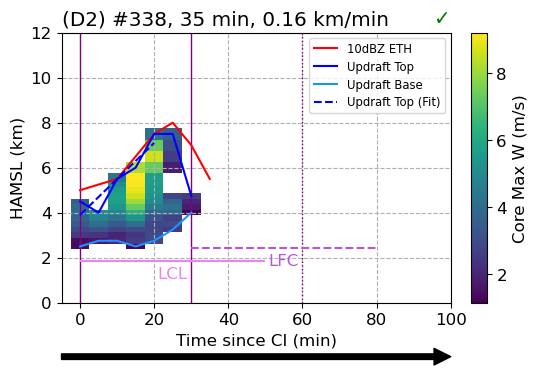

In [97]:
# itrack = 5
itrack = 338

_da = CoreMaxW_up_deep_d2sub.isel(tracks=itrack).transpose()
_maxETH = maxETH_10dbz_deep_d2sub.isel(tracks=itrack)
_da_mask = Wmask_dict_deep_d2sub['Wmask_plt'].isel(tracks=itrack).transpose()
_Wtop = Wmask_dict_deep_d2sub['Wtop'].isel(tracks=itrack)
_Wbase = Wmask_dict_deep_d2sub['Wbase'].isel(tracks=itrack)
_t_s = Wmask_dict_deep_d2sub['Wtime_start'].isel(tracks=itrack)
_t_e = Wmask_dict_deep_d2sub['Wtime_end'].isel(tracks=itrack)
_Wlifetime = Wmask_dict_deep_d2sub['Wlifetime'].isel(tracks=itrack)
_Wtime_startend = {'s':_t_s, 'e':_t_e}
_WtopMax = _Wtop.max(dim='times').item()
_env_dict = {'LCL':LCL_mu_deep_d2sub.isel(tracks=itrack), 'LFC':LFC_mu_deep_d2sub.isel(tracks=itrack)}
_Wtop_fit = Wtop_fit_deep_d2sub[itrack]
_Wtop_slope = Wtop_slope_deep_d2sub[itrack]
_keep_flag = Wkeep_flag_d2sub[itrack]

xlim = (-5,100)
ylim = (0,12)
# title = f'(D2) #{itrack}, {_Wlifetime:.0f} min, {_WtopMax} km, {_Wtop_slope:}'
title = f'(D2) #{itrack}, {_Wlifetime:.0f} min, {_Wtop_slope:.2f} km/min'
xlabel = 'Time since CI (min)'
ylabel = 'HAMSL (km)'
cmap = 'viridis'
cblabels = 'Core Max W (m/s)'
figbasename = 'CoreMaxW'
# cblabels = 'Core Width (km)'
# figbasename = 'CoreWidth'
figdir_sample = f'{figdir}/updraft_tracks/'
os.makedirs(figdir_sample, exist_ok=True)
figname = f'{figdir_sample}{figbasename}_d2_deep_{itrack:04}.png'
figsize = (5,3)
fontsize = 12

fig = plot_tz_sample(xtime, height, _da, _da_mask, _maxETH, _Wtop, _Wtime_startend, _env_dict,
                     cldTop_fit=_Wtop_fit, cldBase=_Wbase, keep_flag=_keep_flag,
                     xlim=xlim, ylim=ylim, title=title, xlabel=xlabel, ylabel=ylabel,
                     cmap=cmap, cblabels=cblabels, fontsize=fontsize, figsize=figsize, figname=figname)
# plt.close(fig)
print(figname)

/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d2_shallow_0032.png


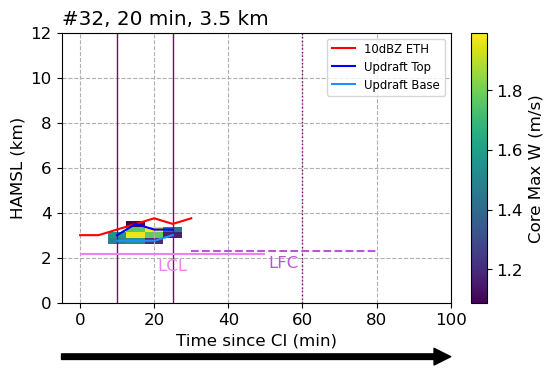

In [98]:
itrack = 32

_da = CoreMaxW_up_shallow_d2sub.isel(tracks=itrack).transpose()
_maxETH = maxETH_10dbz_shallow_d2sub.isel(tracks=itrack)
_da_mask = Wmask_dict_shallow_d2sub['Wmask_plt'].isel(tracks=itrack).transpose()
_Wtop = Wmask_dict_shallow_d2sub['Wtop'].isel(tracks=itrack)
_Wbase = Wmask_dict_shallow_d2sub['Wbase'].isel(tracks=itrack)
_t_s = Wmask_dict_shallow_d2sub['Wtime_start'].isel(tracks=itrack)
_t_e = Wmask_dict_shallow_d2sub['Wtime_end'].isel(tracks=itrack)
_Wlifetime = Wmask_dict_shallow_d2sub['Wlifetime'].isel(tracks=itrack)
_Wtime_startend = {'s':_t_s, 'e':_t_e}
_WtopMax = _Wtop.max(dim='times').item()
_env_dict = {'LCL':LCL_mu_shallow_d2sub.isel(tracks=itrack), 'LFC':LFC_mu_shallow_d2sub.isel(tracks=itrack)}

xlim = (-5,100)
ylim = (0,12)
title = f'#{itrack}, {_Wlifetime:.0f} min, {_WtopMax} km'
xlabel = 'Time since CI (min)'
ylabel = 'HAMSL (km)'
cmap = 'viridis'
cblabels = 'Core Max W (m/s)'
figbasename = 'CoreMaxW'
# cblabels = 'Core Width (km)'
# figbasename = 'CoreWidth'
figdir_sample = f'{figdir}/updraft_tracks/'
os.makedirs(figdir_sample, exist_ok=True)

figname = f'{figdir_sample}{figbasename}_d2_shallow_{itrack:04}.png'
figsize = (5,3)
fontsize = 12

fig = plot_tz_sample(xtime, height, _da, _da_mask, _maxETH, _Wtop, _Wtime_startend, _env_dict,
                     cldBase=_Wbase,
                     xlim=xlim, ylim=ylim, title=title, xlabel=xlabel, ylabel=ylabel,
                     cmap=cmap, cblabels=cblabels, fontsize=fontsize, figsize=figsize, figname=figname)
# plt.close(fig)
print(figname)

In [99]:
figdir_sample

'/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/'

In [100]:
# for itrack in range(0, CoreMaxW_up_deep_d2sub.sizes['tracks']):
#     print(itrack)

In [101]:
# Set a seed for reproducibility
np.random.seed(10)

nsamples2plot = 300
tracks_random = np.random.randint(0, CoreMaxW_up_shallow_d2sub.sizes['tracks'], nsamples2plot)
tracks_random

array([265, 125,  15, 123, 156, 221,   8,  73, 256,  40,  16, 239,  54,
       122,  62,  33, 200, 177, 179,  54,  77,  13, 243, 141, 158,  89,
       140,  31,  18,  93,  77,  94, 248, 156,  74, 216,  15,  18, 118,
        71, 145, 135, 203, 250,  44, 133,   4,  71, 182, 271, 143, 134,
       246,  85, 234, 150,  11, 112, 268, 220,  62, 185,  79, 232,  42,
       237, 235,  45, 201, 165, 128,  23,   3, 272, 112,  14,  51,  79,
       243, 273, 178,  53, 234, 273, 233,  41,  90, 268, 209, 144, 128,
       159, 201, 244, 254,  22,  96,  67,  95,  82,  62, 246,  77,  48,
       237, 115, 267,  95, 171, 224, 229,  73, 168, 235,  71, 136, 213,
       255,  30, 123, 153, 206, 213,  13, 169,   4, 215,  28,  39, 103,
       265, 263, 150,  32, 259,   9, 180, 196, 158, 137, 258, 115, 141,
       133, 221, 162, 168,  46,  86, 186,  18,  44, 205,  18,  83, 165,
       103, 143,  55,   9,   0,  44, 270, 117,  42, 201,  44, 251,  40,
       144, 209,  39,  49, 127, 206,  21,   3, 204, 145, 178,  5

In [255]:
# for itrack in tracks_random:
#     _Wbase = Wmask_dict_deep_d2sub['Wbase'].isel(tracks=itrack)
#     print(itrack, _Wbase)

In [256]:
# Generate a random number of tracks
tracks_random = np.random.randint(0, CoreMaxW_up_deep_d2sub.sizes['tracks'], nsamples2plot)

# Loop over each track to plot
for itrack in tracks_random:
    _da = CoreMaxW_up_deep_d2sub.isel(tracks=itrack).transpose()
    _maxETH = maxETH_10dbz_deep_d2sub.isel(tracks=itrack)
    _da_mask = Wmask_dict_deep_d2sub['Wmask_plt'].isel(tracks=itrack).transpose()
    _Wtop = Wmask_dict_deep_d2sub['Wtop'].isel(tracks=itrack)
    _Wbase = Wmask_dict_deep_d2sub['Wbase'].isel(tracks=itrack)
    _t_s = Wmask_dict_deep_d2sub['Wtime_start'].isel(tracks=itrack)
    _t_e = Wmask_dict_deep_d2sub['Wtime_end'].isel(tracks=itrack)
    _Wlifetime = Wmask_dict_deep_d2sub['Wlifetime'].isel(tracks=itrack)
    _Wtime_startend = {'s':_t_s, 'e':_t_e}
    _WtopMax = _Wtop.max(dim='times').item()
    _env_dict = {'LCL':LCL_mu_deep_d2sub.isel(tracks=itrack), 'LFC':LFC_mu_deep_d2sub.isel(tracks=itrack)}
    _Wtop_fit = Wtop_fit_deep_d2sub[itrack]
    _Wtop_slope = Wtop_slope_deep_d2sub[itrack]
    _keep_flag = Wkeep_flag_d2sub[itrack]

    xlim = (-5,100)
    ylim = (0,12)
    # title = f'(D2) #{itrack}, {_Wlifetime:.0f} min, {_WtopMax} km'
    title = f'(D2) #{itrack}, {_Wlifetime:.0f} min, {_Wtop_slope:.2f} km/min'
    xlabel = 'Time since CI (min)'
    ylabel = 'HAMSL (km)'
    cmap = 'viridis'
    cblabels = 'Core Max W (m/s)'
    figbasename = 'CoreMaxW'
    # cblabels = 'Core Width (km)'
    # figbasename = 'CoreWidth'
    figdir_sample = f'{figdir}/updraft_tracks/'
    figname = f'{figdir_sample}{figbasename}_d2_deep_{itrack:04}.png'
    figsize = (5,3)
    fontsize = 12
   
    fig = plot_tz_sample(xtime, height, _da, _da_mask, _maxETH, _Wtop, _Wtime_startend, _env_dict,
                     cldTop_fit=_Wtop_fit, cldBase=_Wbase, keep_flag=_keep_flag,
                     xlim=xlim, ylim=ylim, title=title, xlabel=xlabel, ylabel=ylabel,
                     cmap=cmap, cblabels=cblabels, fontsize=fontsize, figsize=figsize, figname=figname)
    
    plt.close(fig)
    print(figname)

/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d2_deep_0005.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d2_deep_0247.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d2_deep_0710.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d2_deep_0189.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d2_deep_0232.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d2_deep_0714.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d2_deep_0644.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d2_deep_0597.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d2_deep_0713.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d2_deep_0291.png
/gpfs/wolf/atm131/proj-shared/zfeng/cact

In [122]:
# Generate a random number of tracks
tracks_random = np.random.randint(0, CoreMaxW_up_shallow_d2sub.sizes['tracks'], nsamples2plot)

# Loop over each track to plot
for itrack in tracks_random:
    _da = CoreMaxW_up_shallow_d2sub.isel(tracks=itrack).transpose()
    _maxETH = maxETH_10dbz_shallow_d2sub.isel(tracks=itrack)
    _da_mask = Wmask_dict_shallow_d2sub['Wmask_plt'].isel(tracks=itrack).transpose()
    _Wtop = Wmask_dict_shallow_d2sub['Wtop'].isel(tracks=itrack)
    _Wbase = Wmask_dict_shallow_d2sub['Wbase'].isel(tracks=itrack)
    _t_s = Wmask_dict_shallow_d2sub['Wtime_start'].isel(tracks=itrack)
    _t_e = Wmask_dict_shallow_d2sub['Wtime_end'].isel(tracks=itrack)
    _Wlifetime = Wmask_dict_shallow_d2sub['Wlifetime'].isel(tracks=itrack)
    _Wtime_startend = {'s':_t_s, 'e':_t_e}
    _WtopMax = _Wtop.max(dim='times').item()
    _env_dict = {'LCL':LCL_mu_shallow_d2sub.isel(tracks=itrack), 'LFC':LFC_mu_shallow_d2sub.isel(tracks=itrack)}

    xlim = (-5,100)
    ylim = (0,12)
    title = f'(D2) #{itrack}, {_Wlifetime:.0f} min, {_WtopMax} km'
    xlabel = 'Time since CI (min)'
    ylabel = 'HAMSL (km)'
    cmap = 'viridis'
    cblabels = 'Core Max W (m/s)'
    figbasename = 'CoreMaxW'
    # cblabels = 'Core Width (km)'
    # figbasename = 'CoreWidth'
    figdir_sample = f'{figdir}/updraft_tracks/'
    figname = f'{figdir_sample}{figbasename}_d2_shallow_{itrack:04}.png'
    figsize = (5,3)
    fontsize = 12

    fig = plot_tz_sample(xtime, height, _da, _da_mask, _maxETH, _Wtop, _Wtime_startend, _env_dict,
                         cldBase=_Wbase,
                         xlim=xlim, ylim=ylim, title=title, xlabel=xlabel, ylabel=ylabel,
                         cmap=cmap, cblabels=cblabels, fontsize=fontsize, figsize=figsize, figname=figname)
    plt.close(fig)
    print(figname)

/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d2_shallow_0048.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d2_shallow_0155.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d2_shallow_0177.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d2_shallow_0265.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d2_shallow_0283.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d2_shallow_0113.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d2_shallow_0023.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d2_shallow_0147.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d2_shallow_0048.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d2_shallow_0225.png
/gpfs/wolf

In [269]:
# Generate a random number of tracks
tracks_random = np.random.randint(0, CoreMaxW_up_deep_d3sub.sizes['tracks'], nsamples2plot)

# Loop over each track to plot
for itrack in tracks_random:
    _da = CoreMaxW_up_deep_d3sub.isel(tracks=itrack).transpose()
    _maxETH = maxETH_10dbz_deep_d3sub.isel(tracks=itrack)
    _da_mask = Wmask_dict_deep_d3sub['Wmask_plt'].isel(tracks=itrack).transpose()
    _Wtop = Wmask_dict_deep_d3sub['Wtop'].isel(tracks=itrack)
    _Wbase = Wmask_dict_deep_d3sub['Wbase'].isel(tracks=itrack)
    _t_s = Wmask_dict_deep_d3sub['Wtime_start'].isel(tracks=itrack)
    _t_e = Wmask_dict_deep_d3sub['Wtime_end'].isel(tracks=itrack)
    _Wlifetime = Wmask_dict_deep_d3sub['Wlifetime'].isel(tracks=itrack)
    _Wtime_startend = {'s':_t_s, 'e':_t_e}
    _WtopMax = _Wtop.max(dim='times').item()
    _env_dict = {'LCL':LCL_mu_deep_d3sub.isel(tracks=itrack), 'LFC':LFC_mu_deep_d3sub.isel(tracks=itrack)}
    _Wtop_fit = Wtop_fit_deep_d3sub[itrack]
    _Wtop_slope = Wtop_slope_deep_d3sub[itrack]
    _keep_flag = Wkeep_flag_d3sub[itrack]

    xlim = (-5,100)
    ylim = (0,12)
    title = f'(D3) #{itrack}, {_Wlifetime:.0f} min, {_Wtop_slope:.02f} km/min'
    xlabel = 'Time since CI (min)'
    ylabel = 'HAMSL (km)'
    cmap = 'viridis'
    cblabels = 'Core Max W (m/s)'
    figbasename = 'CoreMaxW'
    # cblabels = 'Core Width (km)'
    # figbasename = 'CoreWidth'
    figdir_sample = f'{figdir}/updraft_tracks/'
    figname = f'{figdir_sample}{figbasename}_d3_deep_{itrack:04}.png'
    figsize = (5,3)
    fontsize = 12

    fig = plot_tz_sample(xtime, height, _da, _da_mask, _maxETH, _Wtop, _Wtime_startend, _env_dict,
                         cldTop_fit=_Wtop_fit, cldBase=_Wbase, keep_flag=_keep_flag,
                         xlim=xlim, ylim=ylim, title=title, xlabel=xlabel, ylabel=ylabel,
                         cmap=cmap, cblabels=cblabels, fontsize=fontsize, figsize=figsize, figname=figname)
    plt.close(fig)
    print(figname)

/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d3_deep_0227.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d3_deep_0160.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d3_deep_0727.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d3_deep_0943.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d3_deep_1327.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d3_deep_1248.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d3_deep_0355.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d3_deep_0785.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d3_deep_0352.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d3_deep_1120.png
/gpfs/wolf/atm131/proj-shared/zfeng/cact

/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/matplotlib/axes/_base.py:2480: UserWarning: Warning: converting a masked element to nan.
  xys = np.asarray(xys)
posx and posy should be finite values
posx and posy should be finite values


/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d3_deep_1036.png


posx and posy should be finite values
posx and posy should be finite values


/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d3_deep_0622.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d3_deep_0049.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d3_deep_1245.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d3_deep_0499.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d3_deep_0569.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d3_deep_0487.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d3_deep_1141.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d3_deep_0476.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d3_deep_1318.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d3_deep_1021.png
/gpfs/wolf/atm131/proj-shared/zfeng/cact

In [136]:
# Generate a random number of tracks
tracks_random = np.random.randint(0, CoreMaxW_up_shallow_d3sub.sizes['tracks'], nsamples2plot)

# Loop over each track to plot
for itrack in tracks_random:
    _da = CoreMaxW_up_shallow_d3sub.isel(tracks=itrack).transpose()
    _maxETH = maxETH_10dbz_shallow_d3sub.isel(tracks=itrack)
    _da_mask = Wmask_dict_shallow_d3sub['Wmask_plt'].isel(tracks=itrack).transpose()
    _Wtop = Wmask_dict_shallow_d3sub['Wtop'].isel(tracks=itrack)
    _Wbase = Wmask_dict_shallow_d3sub['Wbase'].isel(tracks=itrack)
    _t_s = Wmask_dict_shallow_d3sub['Wtime_start'].isel(tracks=itrack)
    _t_e = Wmask_dict_shallow_d3sub['Wtime_end'].isel(tracks=itrack)
    _Wlifetime = Wmask_dict_shallow_d3sub['Wlifetime'].isel(tracks=itrack)
    _Wtime_startend = {'s':_t_s, 'e':_t_e}
    _WtopMax = _Wtop.max(dim='times').item()
    _env_dict = {'LCL':LCL_mu_shallow_d3sub.isel(tracks=itrack), 'LFC':LFC_mu_shallow_d3sub.isel(tracks=itrack)}

    xlim = (-5,100)
    ylim = (0,12)
    title = f'(D3) #{itrack}, {_Wlifetime:.0f} min, {_WtopMax} km'
    xlabel = 'Time since CI (min)'
    ylabel = 'HAMSL (km)'
    cmap = 'viridis'
    cblabels = 'Core Max W (m/s)'
    figbasename = 'CoreMaxW'
    # cblabels = 'Core Width (km)'
    # figbasename = 'CoreWidth'
    figdir_sample = f'{figdir}/updraft_tracks/'
    figname = f'{figdir_sample}{figbasename}_d3_shallow_{itrack:04}.png'
    figsize = (5,3)
    fontsize = 12

    fig = plot_tz_sample(xtime, height, _da, _da_mask, _maxETH, _Wtop, _Wtime_startend, _env_dict,
                         cldBase=_Wbase,
                         xlim=xlim, ylim=ylim, title=title, xlabel=xlabel, ylabel=ylabel,
                         cmap=cmap, cblabels=cblabels, fontsize=fontsize, figsize=figsize, figname=figname)
    plt.close(fig)
    print(figname)

/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d3_shallow_0505.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d3_shallow_0083.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d3_shallow_0019.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d3_shallow_0063.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d3_shallow_0351.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d3_shallow_0473.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d3_shallow_0547.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d3_shallow_0094.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d3_shallow_0322.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d3_shallow_0251.png
/gpfs/wolf

In [270]:
# Generate a random number of tracks
tracks_random = np.random.randint(0, CoreMaxW_up_deep_d4sub.sizes['tracks'], nsamples2plot)

# Loop over each track to plot
for itrack in tracks_random:
    _da = CoreMaxW_up_deep_d4sub.isel(tracks=itrack).transpose()
    _maxETH = maxETH_10dbz_deep_d4sub.isel(tracks=itrack)
    _da_mask = Wmask_dict_deep_d4sub['Wmask_plt'].isel(tracks=itrack).transpose()
    _Wtop = Wmask_dict_deep_d4sub['Wtop'].isel(tracks=itrack)
    _Wbase = Wmask_dict_deep_d4sub['Wbase'].isel(tracks=itrack)
    _t_s = Wmask_dict_deep_d4sub['Wtime_start'].isel(tracks=itrack)
    _t_e = Wmask_dict_deep_d4sub['Wtime_end'].isel(tracks=itrack)
    _Wlifetime = Wmask_dict_deep_d4sub['Wlifetime'].isel(tracks=itrack)
    _Wtime_startend = {'s':_t_s, 'e':_t_e}
    _WtopMax = _Wtop.max(dim='times').item()
    _env_dict = {'LCL':LCL_mu_deep_d4sub.isel(tracks=itrack), 'LFC':LFC_mu_deep_d4sub.isel(tracks=itrack)}
    _Wtop_fit = Wtop_fit_deep_d4sub[itrack]
    _Wtop_slope = Wtop_slope_deep_d4sub[itrack]
    _keep_flag = Wkeep_flag_d4sub[itrack]

    xlim = (-5,100)
    ylim = (0,12)
    title = f'(D4) #{itrack}, {_Wlifetime:.0f} min, {_Wtop_slope:.02f} km/min'
    xlabel = 'Time since CI (min)'
    ylabel = 'HAMSL (km)'
    cmap = 'viridis'
    cblabels = 'Core Max W (m/s)'
    figbasename = 'CoreMaxW'
    # cblabels = 'Core Width (km)'
    # figbasename = 'CoreWidth'
    figdir_sample = f'{figdir}/updraft_tracks/'
    figname = f'{figdir_sample}{figbasename}_d4_deep_{itrack:04}.png'
    figsize = (5,3)
    fontsize = 12

    fig = plot_tz_sample(xtime, height, _da, _da_mask, _maxETH, _Wtop, _Wtime_startend, _env_dict,
                         cldTop_fit=_Wtop_fit, cldBase=_Wbase, keep_flag=_keep_flag,
                         xlim=xlim, ylim=ylim, title=title, xlabel=xlabel, ylabel=ylabel,
                         cmap=cmap, cblabels=cblabels, fontsize=fontsize, figsize=figsize, figname=figname)
    plt.close(fig)
    print(figname)

/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_deep_1502.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_deep_0873.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_deep_1219.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_deep_1332.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_deep_1240.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_deep_0682.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_deep_0357.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_deep_1401.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_deep_0132.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_deep_1366.png
/gpfs/wolf/atm131/proj-shared/zfeng/cact

/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/matplotlib/axes/_base.py:2480: UserWarning: Warning: converting a masked element to nan.
  xys = np.asarray(xys)
posx and posy should be finite values
posx and posy should be finite values


/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_deep_0150.png


posx and posy should be finite values
posx and posy should be finite values


/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_deep_0748.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_deep_0215.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_deep_1125.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_deep_0407.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_deep_0687.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_deep_1529.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_deep_0198.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_deep_0477.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_deep_1159.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_deep_1083.png
/gpfs/wolf/atm131/proj-shared/zfeng/cact

/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/matplotlib/axes/_base.py:2480: UserWarning: Warning: converting a masked element to nan.
  xys = np.asarray(xys)
posx and posy should be finite values
posx and posy should be finite values


/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_deep_0322.png


posx and posy should be finite values
posx and posy should be finite values


/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_deep_0749.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_deep_0901.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_deep_1176.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_deep_1044.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_deep_1397.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_deep_1439.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_deep_0859.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_deep_0144.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_deep_1435.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_deep_1116.png
/gpfs/wolf/atm131/proj-shared/zfeng/cact

In [138]:
# Generate a random number of tracks
tracks_random = np.random.randint(0, CoreMaxW_up_shallow_d4sub.sizes['tracks'], nsamples2plot)

# Loop over each track to plot
for itrack in tracks_random:
    _da = CoreMaxW_up_shallow_d4sub.isel(tracks=itrack).transpose()
    _maxETH = maxETH_10dbz_shallow_d4sub.isel(tracks=itrack)
    _da_mask = Wmask_dict_shallow_d4sub['Wmask_plt'].isel(tracks=itrack).transpose()
    _Wtop = Wmask_dict_shallow_d4sub['Wtop'].isel(tracks=itrack)
    _Wbase = Wmask_dict_shallow_d4sub['Wbase'].isel(tracks=itrack)
    _t_s = Wmask_dict_shallow_d4sub['Wtime_start'].isel(tracks=itrack)
    _t_e = Wmask_dict_shallow_d4sub['Wtime_end'].isel(tracks=itrack)
    _Wlifetime = Wmask_dict_shallow_d4sub['Wlifetime'].isel(tracks=itrack)
    _Wtime_startend = {'s':_t_s, 'e':_t_e}
    _WtopMax = _Wtop.max(dim='times').item()
    _env_dict = {'LCL':LCL_mu_shallow_d4sub.isel(tracks=itrack), 'LFC':LFC_mu_shallow_d4sub.isel(tracks=itrack)}

    xlim = (-5,100)
    ylim = (0,12)
    title = f'(D4) #{itrack}, {_Wlifetime:.0f} min, {_WtopMax} km'
    xlabel = 'Time since CI (min)'
    ylabel = 'HAMSL (km)'
    cmap = 'viridis'
    cblabels = 'Core Max W (m/s)'
    figbasename = 'CoreMaxW'
    # cblabels = 'Core Width (km)'
    # figbasename = 'CoreWidth'
    figdir_sample = f'{figdir}/updraft_tracks/'
    figname = f'{figdir_sample}{figbasename}_d4_shallow_{itrack:04}.png'
    figsize = (5,3)
    fontsize = 12

    fig = plot_tz_sample(xtime, height, _da, _da_mask, _maxETH, _Wtop, _Wtime_startend, _env_dict,
                         cldBase=_Wbase,
                         xlim=xlim, ylim=ylim, title=title, xlabel=xlabel, ylabel=ylabel,
                         cmap=cmap, cblabekeep_flag=els, fontsize=fontsize, figsize=figsize, figname=figname)
    plt.close(fig)
    print(figname)

/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_shallow_0468.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_shallow_0393.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_shallow_0587.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_shallow_0205.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_shallow_0286.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_shallow_0249.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_shallow_0253.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_shallow_0302.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_shallow_0079.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_shallow_0410.png
/gpfs/wolf

## Subset deep cell DataSets for final analysis

In [204]:
# Get track indices from the keep flag
trackID_Wkeep_d2sub = Wkeep_flag_d2sub.where(Wkeep_flag_d2sub, drop=True).tracks.data
# Subset the deep cell DataSet for tracks to keep
ds_deep_final_d2 = dss_deep_d2sub.sel(tracks=trackID_Wkeep_d2sub).chunk(dict(tracks=-1))
# Subset deep updraft mask to keep
Wmask_deep_final_d2 = Wmask_dict_deep_d2sub['Wmask'].sel(tracks=trackID_Wkeep_d2sub)

# Shallow cell DataSet is final
ds_shallow_final_d2 = dss_shallow_d2sub.chunk(dict(tracks=-1))
ds_shallow_final_d2

# Get number of final tracks
ntracks_shallow_d2 = ds_shallow_final_d2.sizes['tracks']
ntracks_deep_d2 = ds_deep_final_d2.sizes['tracks']
print(f'Final number of tracks for D2')
print(f'Shallow: {ntracks_shallow_d2}')
print(f'Deep: {ntracks_deep_d2}')

Final number of tracks for D2
Shallow: 451
Deep: 465


In [205]:
# Get track indices from the keep flag
trackID_Wkeep_d3sub = Wkeep_flag_d3sub.where(Wkeep_flag_d3sub, drop=True).tracks.data
# Subset the deep cell DataSet for tracks to keep
ds_deep_final_d3 = dss_deep_d3sub.sel(tracks=trackID_Wkeep_d3sub).chunk(dict(tracks=-1))
# Subset deep updraft mask to keep
Wmask_deep_final_d3 = Wmask_dict_deep_d3sub['Wmask'].sel(tracks=trackID_Wkeep_d3sub)

# Shallow cell DataSet is final
ds_shallow_final_d3 = dss_shallow_d3sub.chunk(dict(tracks=-1))
ds_shallow_final_d3

# Get number of final tracks
ntracks_shallow_d3 = ds_shallow_final_d3.sizes['tracks']
ntracks_deep_d3 = ds_deep_final_d3.sizes['tracks']
print(f'Final number of tracks for D3')
print(f'Shallow: {ntracks_shallow_d3}')
print(f'deep: {ntracks_deep_d3}')

Final number of tracks for D3
Shallow: 1491
deep: 770


In [206]:
# Get track indices from the keep flag
trackID_Wkeep_d4sub = Wkeep_flag_d4sub.where(Wkeep_flag_d4sub, drop=True).tracks.data
# Subset the deep cell DataSet for tracks to keep
ds_deep_final_d4 = dss_deep_d4sub.sel(tracks=trackID_Wkeep_d4sub).chunk(dict(tracks=-1))
# Subset deep updraft mask to keep
Wmask_deep_final_d4 = Wmask_dict_deep_d4sub['Wmask'].sel(tracks=trackID_Wkeep_d4sub)

# Shallow cell DataSet is final
ds_shallow_final_d4 = dss_shallow_d4sub.chunk(dict(tracks=-1))
ds_shallow_final_d4

# Get number of final tracks
ntracks_shallow_d4 = ds_shallow_final_d4.sizes['tracks']
ntracks_deep_d4 = ds_deep_final_d4.sizes['tracks']
print(f'Final number of tracks for D4')
print(f'Shallow: {ntracks_shallow_d4}')
print(f'deep: {ntracks_deep_d4}')

Final number of tracks for D4
Shallow: 1512
deep: 832


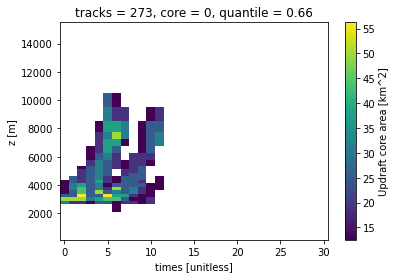

In [207]:
# Example to mask first updraft core and select a track to plot
ds_deep_final_d2.CoreArea_up.isel(core=0).where(Wmask_deep_final_d2 == 1).isel(tracks=29).transpose().sel(times=slice(0,30), z=slice(0,15000)).plot()

In [208]:
# _area = ds_deep_final_d2.CoreArea_up.isel(tracks=10, core=0).transpose().sel(times=slice(0,30))
# _area.plot()

In [209]:
# _mask = Wmask_dict_deep_d2sub['Wmask'].sel(tracks=trackID_Wkeep_d2sub).isel(tracks=10).transpose().sel(times=slice(0,30))
# _mask.plot()

In [210]:
# _area.where(_mask == 1).plot()

## Compute lifetime-max updraft statistics

In [222]:
ds_deep_final_d2

<xarray.Dataset>
Dimensions:                  (tracks: 465, times: 212, height: 101, z: 40,
                              core: 20)
Coordinates:
  * tracks                   (tracks) int64 1 3 4 5 11 ... 3978 3990 4026 4027
  * times                    (times) int64 -12 -11 -10 -9 -8 ... 196 197 198 199
  * height                   (height) float64 0.0 200.0 400.0 ... 1.98e+04 2e+04
  * z                        (z) float64 250.0 500.0 750.0 ... 2e+04 2.1e+04
  * core                     (core) int64 0 1 2 3 4 5 6 ... 13 14 15 16 17 18 19
    quantile                 float64 0.66
Data variables: (12/188)
    temperature              (tracks, times, height) float32 dask.array<chunksize=(465, 212, 101), meta=np.ndarray>
    qv                       (tracks, times, height) float32 dask.array<chunksize=(465, 212, 101), meta=np.ndarray>
    rh                       (tracks, times, height) float32 dask.array<chunksize=(465, 212, 101), meta=np.ndarray>
    pressure                 (tracks, times, height) float32 dask.array<chunksize=(465, 212, 101), meta=np.ndarray>
    u                        (tracks, times, height) float32 dask.array<chunksize=(465, 212, 101), meta=np.ndarray>
    v                        (tracks, times, height) float32 dask.array<chunksize=(465, 212, 101), meta=np.ndarray>
    ...                       ...
    start_split_tracknumber  (tracks) float64 dask.array<chunksize=(465,), meta=np.ndarray>
    start_split_timeindex    (tracks) float64 dask.array<chunksize=(465,), meta=np.ndarray>
    start_split_cloudnumber  (tracks) float64 dask.array<chunksize=(465,), meta=np.ndarray>
    end_merge_tracknumber    (tracks) float64 dask.array<chunksize=(465,), meta=np.ndarray>
    end_merge_timeindex      (tracks) float64 dask.array<chunksize=(465,), meta=np.ndarray>
    end_merge_cloudnumber    (tracks) float64 dask.array<chunksize=(465,), meta=np.ndarray>
Attributes:
    title:                 Tracked cell W statistics
    source_trackfile:      /gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso/201...
    startdate:             20181129.1200
    enddate:               20181130.0000
    timegap_hour:          0.5
    time_resolution_hour:  0.08333
    pixel_radius_km:       2.5

In [223]:
prof_quantiles = [0.25, 0.5, 0.75]

# Suppress RuntimeWarning messages
warnings.filterwarnings("ignore", category=RuntimeWarning)

# Deep
trackmax_CoreAreaUp_deep_prof_pts_d2 = ds_deep_final_d2.CoreArea_up.isel(core=0).where(Wmask_deep_final_d2 == 1).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmax_CoreMeanWUp_deep_prof_pts_d2 = ds_deep_final_d2.CoreMeanW_up.isel(core=0).where(Wmask_deep_final_d2 == 1).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmax_CoreMaxWUp_deep_prof_pts_d2 = ds_deep_final_d2.CoreMaxW_up.isel(core=0).where(Wmask_deep_final_d2 == 1).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmax_CoreMassfluxUp_deep_prof_pts_d2 = ds_deep_final_d2.CoreMassFlux_up.isel(core=0).where(Wmask_deep_final_d2 == 1).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmax_MassfluxUp_deep_prof_pts_d2 = ds_deep_final_d2.MassFlux_up.where(Wmask_deep_final_d2 == 1).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmax_CoreThteMaxUp_deep_prof_pts_d2 = ds_deep_final_d2.CoreThteMax_up.isel(core=0).where(Wmask_deep_final_d2 == 1).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmax_CoreBuoyThtvUp_deep_prof_pts_d2 = ds_deep_final_d2.CoreBuoyThtv_up.isel(core=0).where(Wmask_deep_final_d2 == 1).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
# Shallow
trackmax_CoreAreaUp_shallow_prof_pts_d2 = ds_shallow_final_d2.CoreArea_up.isel(core=0).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmax_CoreMeanWUp_shallow_prof_pts_d2 = ds_shallow_final_d2.CoreMeanW_up.isel(core=0).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmax_CoreMaxWUp_shallow_prof_pts_d2 = ds_shallow_final_d2.CoreMaxW_up.isel(core=0).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmax_CoreMassfluxUp_shallow_prof_pts_d2 = ds_shallow_final_d2.CoreMassFlux_up.isel(core=0).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmax_MassfluxUp_shallow_prof_pts_d2 = ds_shallow_final_d2.MassFlux_up.max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmax_CoreThteMaxUp_shallow_prof_pts_d2 = ds_shallow_final_d2.CoreThteMax_up.isel(core=0).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmax_CoreBuoyThtvUp_shallow_prof_pts_d2 = ds_shallow_final_d2.CoreBuoyThtv_up.isel(core=0).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()

# Number of sample at each time & height for all tracks
nsample_CoreAreaUp_shallow_d2 = (ds_shallow_final_d2.CoreArea_up.isel(core=0) > 0).sum(dim='tracks').load()
nsample_CoreAreaUp_deep_d2 = (ds_deep_final_d4.CoreArea_up.isel(core=0).where(Wmask_deep_final_d4 == 1) > 0).sum(dim='tracks').load()

In [226]:
# Deep
trackmax_CoreAreaUp_deep_prof_pts_d3 = ds_deep_final_d3.CoreArea_up.isel(core=0).where(Wmask_deep_final_d3 == 1).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmax_CoreMeanWUp_deep_prof_pts_d3 = ds_deep_final_d3.CoreMeanW_up.isel(core=0).where(Wmask_deep_final_d3 == 1).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmax_CoreMaxWUp_deep_prof_pts_d3 = ds_deep_final_d3.CoreMaxW_up.isel(core=0).where(Wmask_deep_final_d3 == 1).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmax_CoreMassfluxUp_deep_prof_pts_d3 = ds_deep_final_d3.CoreMassFlux_up.isel(core=0).where(Wmask_deep_final_d3 == 1).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmax_MassfluxUp_deep_prof_pts_d3 = ds_deep_final_d3.MassFlux_up.where(Wmask_deep_final_d3 == 1).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmax_CoreThteMaxUp_deep_prof_pts_d3 = ds_deep_final_d3.CoreThteMax_up.isel(core=0).where(Wmask_deep_final_d3 == 1).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmax_CoreBuoyThtvUp_deep_prof_pts_d3 = ds_deep_final_d3.CoreBuoyThtv_up.isel(core=0).where(Wmask_deep_final_d3 == 1).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
# Shallow
trackmax_CoreAreaUp_shallow_prof_pts_d3 = ds_shallow_final_d3.CoreArea_up.isel(core=0).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmax_CoreMeanWUp_shallow_prof_pts_d3 = ds_shallow_final_d3.CoreMeanW_up.isel(core=0).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmax_CoreMaxWUp_shallow_prof_pts_d3 = ds_shallow_final_d3.CoreMaxW_up.isel(core=0).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmax_CoreMassfluxUp_shallow_prof_pts_d3 = ds_shallow_final_d3.CoreMassFlux_up.isel(core=0).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmax_MassfluxUp_shallow_prof_pts_d3 = ds_shallow_final_d3.MassFlux_up.max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmax_CoreThteMaxUp_shallow_prof_pts_d3 = ds_shallow_final_d3.CoreThteMax_up.isel(core=0).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmax_CoreBuoyThtvUp_shallow_prof_pts_d3 = ds_shallow_final_d3.CoreBuoyThtv_up.isel(core=0).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()

# Number of sample at each time & height for all tracks
nsample_CoreAreaUp_shallow_d3 = (ds_shallow_final_d3.CoreArea_up.isel(core=0) > 0).sum(dim='tracks').load()
nsample_CoreAreaUp_deep_d3 = (ds_deep_final_d4.CoreArea_up.isel(core=0).where(Wmask_deep_final_d4 == 1) > 0).sum(dim='tracks').load()

In [227]:
# Deep
trackmax_CoreAreaUp_deep_prof_pts_d4 = ds_deep_final_d4.CoreArea_up.isel(core=0).where(Wmask_deep_final_d4 == 1).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmax_CoreMeanWUp_deep_prof_pts_d4 = ds_deep_final_d4.CoreMeanW_up.isel(core=0).where(Wmask_deep_final_d4 == 1).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmax_CoreMaxWUp_deep_prof_pts_d4 = ds_deep_final_d4.CoreMaxW_up.isel(core=0).where(Wmask_deep_final_d4 == 1).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmax_CoreMassfluxUp_deep_prof_pts_d4 = ds_deep_final_d4.CoreMassFlux_up.isel(core=0).where(Wmask_deep_final_d4 == 1).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmax_MassfluxUp_deep_prof_pts_d4 = ds_deep_final_d4.MassFlux_up.where(Wmask_deep_final_d4 == 1).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmax_CoreThteMaxUp_deep_prof_pts_d4 = ds_deep_final_d4.CoreThteMax_up.isel(core=0).where(Wmask_deep_final_d4 == 1).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmax_CoreBuoyThtvUp_deep_prof_pts_d4 = ds_deep_final_d4.CoreBuoyThtv_up.isel(core=0).where(Wmask_deep_final_d4 == 1).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
# Shallow
trackmax_CoreAreaUp_shallow_prof_pts_d4 = ds_shallow_final_d4.CoreArea_up.isel(core=0).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmax_CoreMeanWUp_shallow_prof_pts_d4 = ds_shallow_final_d4.CoreMeanW_up.isel(core=0).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmax_CoreMaxWUp_shallow_prof_pts_d4 = ds_shallow_final_d4.CoreMaxW_up.isel(core=0).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmax_CoreMassfluxUp_shallow_prof_pts_d4 = ds_shallow_final_d4.CoreMassFlux_up.isel(core=0).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmax_MassfluxUp_shallow_prof_pts_d4 = ds_shallow_final_d4.MassFlux_up.max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmax_CoreThteMaxUp_shallow_prof_pts_d4 = ds_shallow_final_d4.CoreThteMax_up.isel(core=0).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
trackmax_CoreBuoyThtvUp_shallow_prof_pts_d4 = ds_shallow_final_d4.CoreBuoyThtv_up.isel(core=0).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()

# Number of sample at each time & height for all tracks
nsample_CoreAreaUp_shallow_d4 = (ds_shallow_final_d4.CoreArea_up.isel(core=0) > 0).sum(dim='tracks').load()
nsample_CoreAreaUp_deep_d4 = (ds_deep_final_d4.CoreArea_up.isel(core=0).where(Wmask_deep_final_d4 == 1) > 0).sum(dim='tracks').load()

In [254]:
# Number of sample at each time & height for all tracks
track_ns_init_shallow_d2 = (ds_shallow_final_d2.CoreArea_up.isel(core=0) > 0).sum(dim=('tracks','times')).load()
track_ns_init_deep_d2 = (ds_deep_final_d4.CoreArea_up.isel(core=0).where(Wmask_deep_final_d4 == 1) > 0).sum(dim=('tracks','times')).load()

In [255]:
# Number of sample at each time & height for all tracks
track_ns_init_shallow_d3 = (ds_shallow_final_d3.CoreArea_up.isel(core=0) > 0).sum(dim=('tracks','times')).load()
track_ns_init_deep_d3 = (ds_deep_final_d4.CoreArea_up.isel(core=0).where(Wmask_deep_final_d4 == 1) > 0).sum(dim=('tracks','times')).load()

In [256]:
# Number of sample at each time & height for all tracks
track_ns_init_shallow_d4 = (ds_shallow_final_d4.CoreArea_up.isel(core=0) > 0).sum(dim=('tracks','times')).load()
track_ns_init_deep_d4 = (ds_deep_final_d4.CoreArea_up.isel(core=0).where(Wmask_deep_final_d4 == 1) > 0).sum(dim=('tracks','times')).load()

In [341]:
# trackmax_CoreThteMaxUp_deep_prof_pts_d2 = ds_deep_final_d2.CoreThteMax_up.isel(core=0).where(Wmask_deep_final_d2 == 1).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
# trackmax_CoreThteMaxUp_shallow_prof_pts_d2 = ds_shallow_final_d2.CoreThteMax_up.isel(core=0).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()

In [333]:
# trackmax_CoreThteMaxUp_deep_prof_pts_d3 = ds_deep_final_d3.CoreThteMax_up.isel(core=0).where(Wmask_deep_final_d3 == 1).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
# trackmax_CoreThteMaxUp_shallow_prof_pts_d3 = ds_shallow_final_d3.CoreThteMax_up.isel(core=0).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()

In [348]:
# trackmax_CoreThteMaxUp_deep_prof_pts_d4 = ds_deep_final_d4.CoreThteMax_up.isel(core=0).where(Wmask_deep_final_d4 == 1).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()
# trackmax_CoreThteMaxUp_shallow_prof_pts_d4 = ds_shallow_final_d4.CoreThteMax_up.isel(core=0).max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True).load()

In [351]:
ds_deep_final_d2.CoreThteMax_up.max().values

array(1777.6626, dtype=float32)

In [352]:
ds_deep_final_d3.CoreThteMax_up.max().values

array(1862.0918, dtype=float32)

In [353]:
ds_deep_final_d4.CoreThteMax_up.max().values

array(1909.0205, dtype=float32)

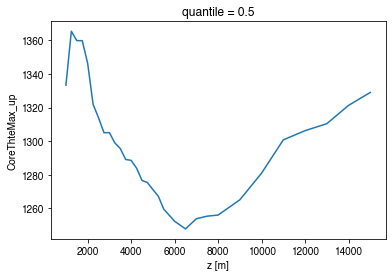

In [347]:
trackmax_CoreThteMaxUp_deep_prof_pts_d2.sel(quantile=0.5).plot()

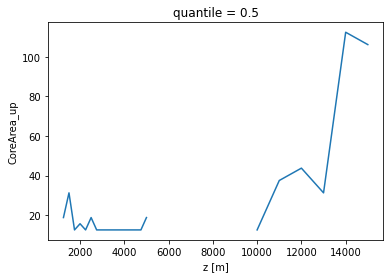

In [218]:
trackmax_CoreAreaUp_shallow_prof_pts_d2.sel(quantile=0.5).plot()

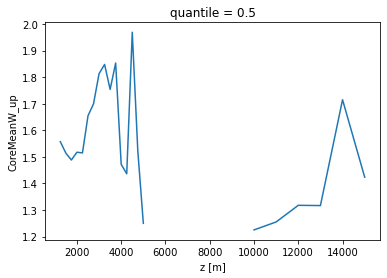

In [219]:
trackmax_CoreMeanWUp_shallow_prof_pts_d2.sel(quantile=0.5).plot()

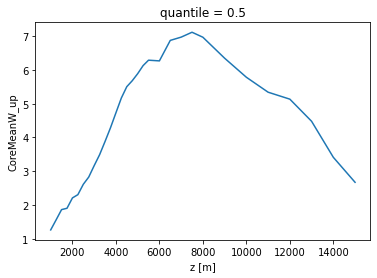

In [215]:
trackmax_CoreMeanWUp_deep_prof_pts_d2.sel(quantile=0.5).plot()

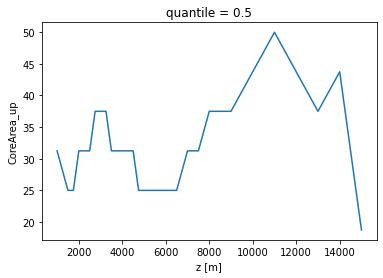

In [213]:
trackmax_CoreAreaUp_deep_prof_pts_d2.sel(quantile=0.5).plot()

In [228]:
# prof_quantiles = [0.25, 0.5, 0.75]
# trackmax_CoreAreaUp_shallow_prof_pts_d2sub = CoreArea_up_shallow_d2sub.max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)
# trackmax_CoreMaxWUp_shallow_prof_pts_d2sub = CoreMaxW_up_shallow_d2sub.max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)

# trackmax_CoreAreaUp_deep_prof_pts_d2sub = CoreArea_up_deep_d2sub.max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)
# trackmax_CoreMaxWUp_deep_prof_pts_d2sub = CoreMaxW_up_deep_d2sub.max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)

In [229]:
# trackmax_CoreAreaUp_shallow_prof_pts_d3sub = CoreArea_up_shallow_d3sub.max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)
# trackmax_CoreMaxWUp_shallow_prof_pts_d3sub = CoreMaxW_up_shallow_d3sub.max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)

# trackmax_CoreAreaUp_deep_prof_pts_d3sub = CoreArea_up_deep_d3sub.max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)
# trackmax_CoreMaxWUp_deep_prof_pts_d3sub = CoreMaxW_up_deep_d3sub.max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)

In [230]:
# trackmax_CoreAreaUp_shallow_prof_pts_d4sub = CoreArea_up_shallow_d4sub.max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)
# trackmax_CoreMaxWUp_shallow_prof_pts_d4sub = CoreMaxW_up_shallow_d4sub.max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)

# trackmax_CoreAreaUp_deep_prof_pts_d4sub = CoreArea_up_deep_d4sub.max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)
# trackmax_CoreMaxWUp_deep_prof_pts_d4sub = CoreMaxW_up_deep_d4sub.max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)

In [239]:
# # Calculate total number of samples
# track_ns_init_shallow_d2 = nsample_CoreArea_up_shallow_d2.sum(dim='times')
# track_ns_init_deep_d2 = nsample_CoreArea_up_deep_d2.sum(dim='times')

In [240]:
# track_ns_init_shallow_d3 = nsample_CoreArea_up_shallow_d3.sum(dim='times')
# track_ns_init_deep_d3 = nsample_CoreArea_up_deep_d3.sum(dim='times')

In [241]:
# track_ns_init_shallow_d4 = nsample_CoreArea_up_shallow_d4.sum(dim='times')
# track_ns_init_deep_d4 = nsample_CoreArea_up_deep_d4.sum(dim='times')

## Function to plot profiles

In [313]:
def plot_profiles(nrows, ncols, height, dict_s, dict_d, dict_s_3profs, dict_d_3profs,
                  legend=None, titles=None, xlables=None, ylabels=None, xlims=None, ylims=None, fontsize=None, figsize=None, figname=None):

    mpl.rcParams['font.size'] = fontsize
    mpl.rcParams['font.family'] = 'Helvetica'
    fig, axes = plt.subplots(nrows, ncols+2, figsize=figsize, dpi=150)
    lw = 4
    colors = {'s': 'dodgerblue', 'd': 'orangered'}
    colors_d = {'d2':'royalblue', 'd3':'lightseagreen', 'd4':'crimson'}
    
    for col in range(ncols):
        ax = axes[col]
        med_shallow = dict_s[col]['line']
        med_deep = dict_d[col]['line']
        fill_shallow = dict_s[col]['fill']
        fill_deep = dict_d[col]['fill']
        
        ax.plot(med_shallow, height, color=colors['s'], lw=lw, label='shallow')
        ax.plot(med_deep, height, color=colors['d'], lw=lw, label='deep')
        ax.fill_betweenx(height, fill_deep[0], fill_deep[1], facecolor=colors['d'], alpha=0.5)
        ax.fill_betweenx(height, fill_shallow[0], fill_shallow[1], facecolor=colors['s'], alpha=0.5)
        ax.grid(ls='--')
        if (ylims is not None): ax.set_ylim(ylims[col][0], ylims[col][1])
        if (xlims is not None): ax.set_xlim(xlims[col][0], xlims[col][1])
        ax.grid(ls='--')
        ax.set_title(titles[col], loc='left')
        ax.set_xlabel(xlabels[col])
        ax.set_ylabel(ylabels[col])
        ax.legend()

    # Second to last column 
    ax = axes[ncols]
    for key in dict_s_3profs.keys():
        med_shallow = dict_s_3profs[key]
        ax.plot(med_shallow, height, color=colors_d[key], lw=lw, label=legend[key])
        ax.grid(ls='--')
        ax.legend()
        ax.set_title(titles[ncols], loc='left')
        ax.set_xlabel(xlabels[ncols])
        if (ylims is not None): ax.set_ylim(ylims[col][0], ylims[col][1])
    # Last column 
    ax = axes[ncols+1]
    for key in dict_s_3profs.keys():
        med_deep = dict_d_3profs[key]
        ax.plot(med_deep, height, color=colors_d[key], lw=lw, label=legend[key])
        ax.grid(ls='--')
        ax.legend()
        ax.set_title(titles[ncols+1], loc='left')
        ax.set_xlabel(xlabels[ncols+1])
        if (ylims is not None): ax.set_ylim(ylims[col][0], ylims[col][1])
        
    fig.tight_layout()
    fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')
    return fig

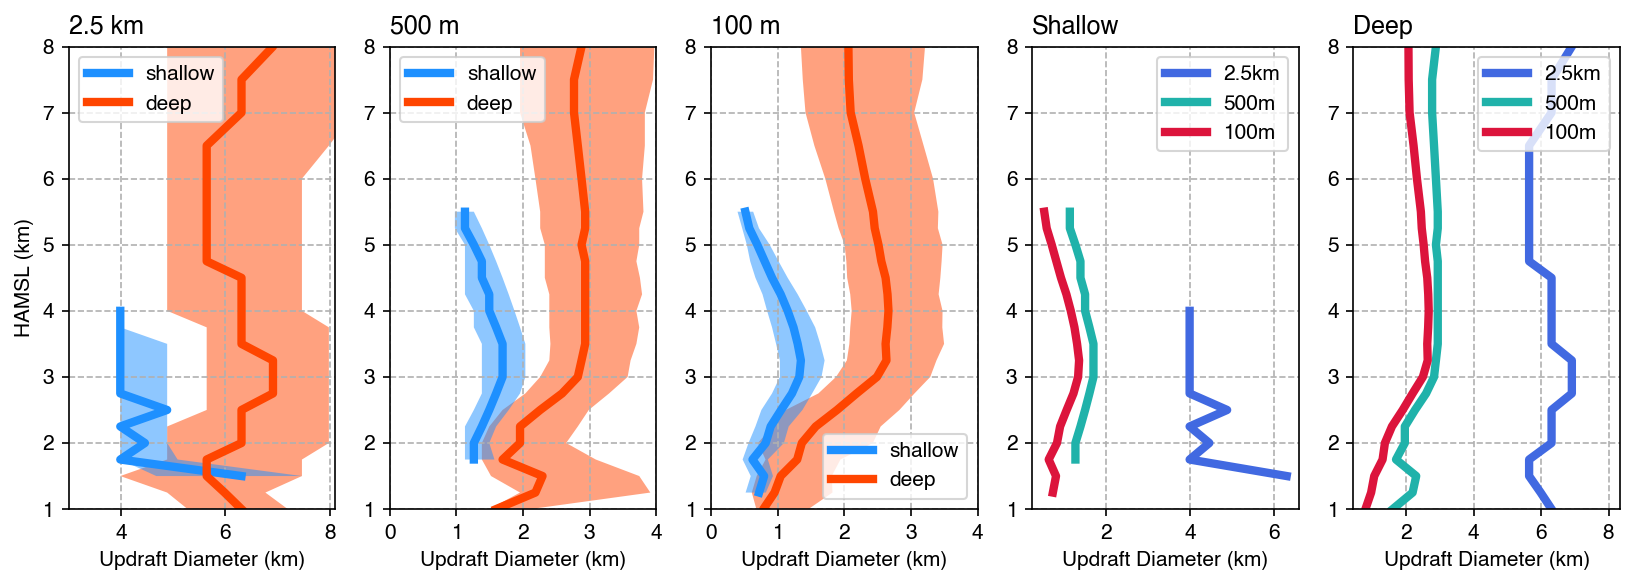

In [321]:
min_ns_shallow = 10
min_ns_deep = 10

# Convert CoreArea to CoreDiameter, filter heights with low samples
prof_s_d2 = np.sqrt(trackmax_CoreAreaUp_shallow_prof_pts_d2.where(track_ns_init_shallow_d2 >= min_ns_shallow)/np.pi)*2
prof_s_d3 = np.sqrt(trackmax_CoreAreaUp_shallow_prof_pts_d3.where(track_ns_init_shallow_d3 >= min_ns_shallow)/np.pi)*2
prof_s_d4 = np.sqrt(trackmax_CoreAreaUp_shallow_prof_pts_d4.where(track_ns_init_shallow_d4 >= min_ns_shallow)/np.pi)*2

prof_d_d2 = np.sqrt(trackmax_CoreAreaUp_deep_prof_pts_d2.where(track_ns_init_deep_d2 >= min_ns_deep)/np.pi)*2
prof_d_d3 = np.sqrt(trackmax_CoreAreaUp_deep_prof_pts_d3.where(track_ns_init_deep_d3 >= min_ns_deep)/np.pi)*2
prof_d_d4 = np.sqrt(trackmax_CoreAreaUp_deep_prof_pts_d4.where(track_ns_init_deep_d4 >= min_ns_deep)/np.pi)*2

dict_s = [
    {
        'line':prof_s_d2.sel(quantile=0.5),
        'fill':[prof_s_d2.sel(quantile=0.25), prof_s_d2.sel(quantile=0.75),],
    },
    {
        'line':prof_s_d3.sel(quantile=0.5),
        'fill':[prof_s_d3.sel(quantile=0.25), prof_s_d3.sel(quantile=0.75),],
    },
    {
        'line':prof_s_d4.sel(quantile=0.5),
        'fill':[prof_s_d4.sel(quantile=0.25), prof_s_d4.sel(quantile=0.75),],
    },
]
dict_d = [
    {
        'line':prof_d_d2.sel(quantile=0.5),
        'fill':[prof_d_d2.sel(quantile=0.25), prof_d_d2.sel(quantile=0.75),],
    },
    {
        'line':prof_d_d3.sel(quantile=0.5),
        'fill':[prof_d_d3.sel(quantile=0.25), prof_d_d3.sel(quantile=0.75),],
    },
    {
        'line':prof_d_d4.sel(quantile=0.5),
        'fill':[prof_d_d4.sel(quantile=0.25), prof_d_d4.sel(quantile=0.75),],
    },
]
dict_s_3profs = {'d2':prof_s_d2.sel(quantile=0.5), 'd3':prof_s_d3.sel(quantile=0.5), 'd4':prof_s_d4.sel(quantile=0.5),}
dict_d_3profs = {'d2':prof_d_d2.sel(quantile=0.5), 'd3':prof_d_d3.sel(quantile=0.5), 'd4':prof_d_d4.sel(quantile=0.5),}
legend_ds = {'d2':'2.5km', 'd3':'500m', 'd4':'100m'}
titles = ['2.5 km', '500 m', '100 m', 'Shallow', 'Deep']
ylabels = ['HAMSL (km)', '', '']
xlabels = ['Updraft Diameter (km)']*5
xlims = [(3,8.1),(0,4),(0,4)]
# xlims = None
ylims = [(1,8)]*3
figsize = (11,4)
fontsize = 10
figname = f'{figdir}Updraft_CoreDiameter_profiles_shallow_deep_d2_d3_d4.png'

fig = plot_profiles(1, 3, height, dict_s, dict_d, dict_s_3profs, dict_d_3profs, legend=legend_ds,
                    titles=titles, xlables=xlabels, ylabels=ylabels, xlims=xlims, ylims=ylims, fontsize=fontsize, figsize=figsize, figname=figname)

In [271]:
# min_ns_shallow = 10
# min_ns_deep = 10

# dict_s = [
#     {
#         'line':trackmax_CoreAreaUp_shallow_prof_pts_d2sub.sel(quantile=0.5).where(track_ns_init_shallow_d2 >= min_ns_shallow),
#         'fill':[trackmax_CoreAreaUp_shallow_prof_pts_d2sub.sel(quantile=0.25).where(track_ns_init_shallow_d2 >= min_ns_shallow),
#                 trackmax_CoreAreaUp_shallow_prof_pts_d2sub.sel(quantile=0.75).where(track_ns_init_shallow_d2 >= min_ns_shallow),],
#     },
#     {
#         'line':trackmax_CoreAreaUp_shallow_prof_pts_d3sub.sel(quantile=0.5).where(track_ns_init_shallow_d3 >= min_ns_shallow),
#         'fill':[trackmax_CoreAreaUp_shallow_prof_pts_d3sub.sel(quantile=0.25).where(track_ns_init_shallow_d3 >= min_ns_shallow),
#                 trackmax_CoreAreaUp_shallow_prof_pts_d3sub.sel(quantile=0.75).where(track_ns_init_shallow_d3 >= min_ns_shallow),],
#     },
#     {
#         'line':trackmax_CoreAreaUp_shallow_prof_pts_d4sub.sel(quantile=0.5).where(track_ns_init_shallow_d4 >= min_ns_shallow),
#         'fill':[trackmax_CoreAreaUp_shallow_prof_pts_d4sub.sel(quantile=0.25).where(track_ns_init_shallow_d4 >= min_ns_shallow),
#                 trackmax_CoreAreaUp_shallow_prof_pts_d4sub.sel(quantile=0.75).where(track_ns_init_shallow_d4 >= min_ns_shallow),],
#     },
# ]
# dict_d = [
#     {
#         'line':trackmax_CoreAreaUp_deep_prof_pts_d2sub.sel(quantile=0.5).where(track_ns_init_deep_d2 >= min_ns_deep),
#         'fill':[trackmax_CoreAreaUp_deep_prof_pts_d2sub.sel(quantile=0.25).where(track_ns_init_deep_d2 >= min_ns_deep),
#                trackmax_CoreAreaUp_deep_prof_pts_d2sub.sel(quantile=0.75).where(track_ns_init_deep_d2 >= min_ns_deep),],
#     },
#     {
#         'line':trackmax_CoreAreaUp_deep_prof_pts_d3sub.sel(quantile=0.5).where(track_ns_init_deep_d3 >= min_ns_deep),
#         'fill':[trackmax_CoreAreaUp_deep_prof_pts_d3sub.sel(quantile=0.25).where(track_ns_init_deep_d3 >= min_ns_deep),
#                trackmax_CoreAreaUp_deep_prof_pts_d3sub.sel(quantile=0.75).where(track_ns_init_deep_d3 >= min_ns_deep),],
#     },
#     {
#         'line':trackmax_CoreAreaUp_deep_prof_pts_d4sub.sel(quantile=0.5).where(track_ns_init_deep_d4 >= min_ns_deep),
#         'fill':[trackmax_CoreAreaUp_deep_prof_pts_d4sub.sel(quantile=0.25).where(track_ns_init_deep_d4 >= min_ns_deep),
#                trackmax_CoreAreaUp_deep_prof_pts_d4sub.sel(quantile=0.75).where(track_ns_init_deep_d4 >= min_ns_deep),],
#     }, 
# ]

# titles = ['2.5 km', '500 m', '100 m']
# ylabels = ['HAMSL (km)', '', '']
# xlabels = ['Updraft Diameter (km)']*3
# xlims = [(10,40),(0,8),(0,8)]
# ylims = [(1,7)]*3
# figsize = (10,4)
# fontsize = 12
# figname = f'{figdir}Updraft_CoreDiameter_profiles_shallow_deep_d2_d3_d4.png'

# fig = plot_profiles(1, 3, height, dict_s, dict_d,
#                     titles=titles, xlables=xlabels, ylabels=ylabels, xlims=xlims, ylims=ylims, fontsize=fontsize, figsize=figsize, figname=figname)

In [273]:
trackmax_CoreMaxWUp_shallow_prof_pts_d3

<xarray.DataArray 'CoreMaxW_up' (quantile: 3, z: 40)>
array([[       nan,        nan,        nan,        nan,        nan,
        2.77101684, 2.93444532, 3.09743118, 3.10838318, 3.52606952,
        3.88294232, 4.12474561, 4.43692207, 4.81978273, 4.94260406,
        4.98112798, 4.77554989, 4.46573424, 4.24779427, 3.90801817,
        3.6839776 , 3.45965862, 2.50134683, 4.72927296,        nan,
               nan,        nan,        nan, 2.73818183, 2.35067582,
        2.21493202, 2.81002176, 2.28510725, 2.61796129,        nan,
               nan,        nan,        nan,        nan,        nan],
       [       nan,        nan,        nan,        nan,        nan,
        3.25258732, 3.39532351, 3.82311296, 3.82073522, 4.29316139,
        4.76293373, 5.07305145, 5.49794722, 5.97479153, 6.30380583,
        6.27462316, 6.20112276, 5.94962525, 5.5539875 , 4.96856618,
        4.72405982, 3.94563341, 4.94416809, 6.08526111,        nan,
               nan,        nan,        nan, 2.73818183, 2.35067582,
        2.27656233, 2.96205258, 2.4094466 , 2.64402032,        nan,
               nan,        nan,        nan,        nan,        nan],
       [       nan,        nan,        nan,        nan,        nan,
        3.39642882, 4.07654309, 4.60607266, 4.71191931, 5.13292789,
        5.6246897 , 6.05811477, 6.64397931, 7.24035478, 7.63446307,
        7.81186318, 7.68850279, 7.50399554, 7.04245913, 6.46025217,
        5.73054183, 4.81742334, 6.73793364, 7.44124925,        nan,
               nan,        nan,        nan, 2.73818183, 2.35067582,
        2.33819264, 3.11408341, 2.53760666, 2.88654387,        nan,
               nan,        nan,        nan,        nan,        nan]])
Coordinates:
  * z         (z) float64 250.0 500.0 750.0 1e+03 ... 1.9e+04 2e+04 2.1e+04
  * quantile  (quantile) float64 0.25 0.5 0.75

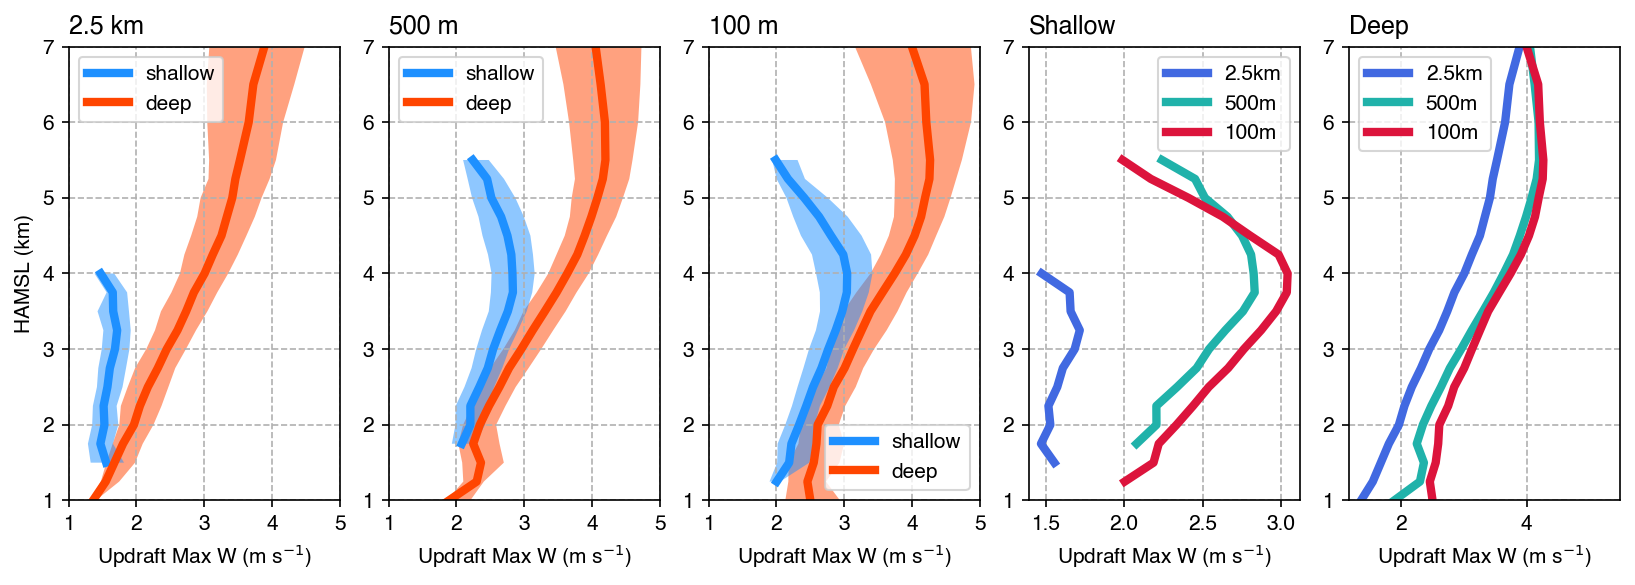

In [324]:
min_ns_shallow = 10
min_ns_deep = 10

# Convert CoreArea to CoreDiameter, filter heights with low samples
prof_s_d2 = np.sqrt(trackmax_CoreMaxWUp_shallow_prof_pts_d2.where(track_ns_init_shallow_d2 >= min_ns_shallow)/np.pi)*2
prof_s_d3 = np.sqrt(trackmax_CoreMaxWUp_shallow_prof_pts_d3.where(track_ns_init_shallow_d3 >= min_ns_shallow)/np.pi)*2
prof_s_d4 = np.sqrt(trackmax_CoreMaxWUp_shallow_prof_pts_d4.where(track_ns_init_shallow_d4 >= min_ns_shallow)/np.pi)*2

prof_d_d2 = np.sqrt(trackmax_CoreMaxWUp_deep_prof_pts_d2.where(track_ns_init_deep_d2 >= min_ns_deep)/np.pi)*2
prof_d_d3 = np.sqrt(trackmax_CoreMaxWUp_deep_prof_pts_d3.where(track_ns_init_deep_d3 >= min_ns_deep)/np.pi)*2
prof_d_d4 = np.sqrt(trackmax_CoreMaxWUp_deep_prof_pts_d4.where(track_ns_init_deep_d4 >= min_ns_deep)/np.pi)*2

dict_s = [
    {
        'line':prof_s_d2.sel(quantile=0.5),
        'fill':[prof_s_d2.sel(quantile=0.25), prof_s_d2.sel(quantile=0.75),],
    },
    {
        'line':prof_s_d3.sel(quantile=0.5),
        'fill':[prof_s_d3.sel(quantile=0.25), prof_s_d3.sel(quantile=0.75),],
    },
    {
        'line':prof_s_d4.sel(quantile=0.5),
        'fill':[prof_s_d4.sel(quantile=0.25), prof_s_d4.sel(quantile=0.75),],
    },
]
dict_d = [
    {
        'line':prof_d_d2.sel(quantile=0.5),
        'fill':[prof_d_d2.sel(quantile=0.25), prof_d_d2.sel(quantile=0.75),],
    },
    {
        'line':prof_d_d3.sel(quantile=0.5),
        'fill':[prof_d_d3.sel(quantile=0.25), prof_d_d3.sel(quantile=0.75),],
    },
    {
        'line':prof_d_d4.sel(quantile=0.5),
        'fill':[prof_d_d4.sel(quantile=0.25), prof_d_d4.sel(quantile=0.75),],
    },
]
dict_s_3profs = {'d2':prof_s_d2.sel(quantile=0.5), 'd3':prof_s_d3.sel(quantile=0.5), 'd4':prof_s_d4.sel(quantile=0.5),}
dict_d_3profs = {'d2':prof_d_d2.sel(quantile=0.5), 'd3':prof_d_d3.sel(quantile=0.5), 'd4':prof_d_d4.sel(quantile=0.5),}
legend_ds = {'d2':'2.5km', 'd3':'500m', 'd4':'100m'}
titles = ['2.5 km', '500 m', '100 m', 'Shallow', 'Deep']
ylabels = ['HAMSL (km)', '', '']
xlabels = ['Updraft Max W (m s$^{-1}$)']*5
xlims = [(1,5),(1,5),(1,5)]
# xlims = None
ylims = [(1,7)]*5
figsize = (11,4)
fontsize = 10
figname = f'{figdir}Updraft_CoreMaxW_profiles_shallow_deep_d2_d3_d4.png'

# ylims
fig = plot_profiles(1, 3, height, dict_s, dict_d, dict_s_3profs, dict_d_3profs,
                    legend=legend_ds, titles=titles, xlables=xlabels, ylabels=ylabels, xlims=xlims, ylims=ylims, fontsize=fontsize, figsize=figsize, figname=figname)

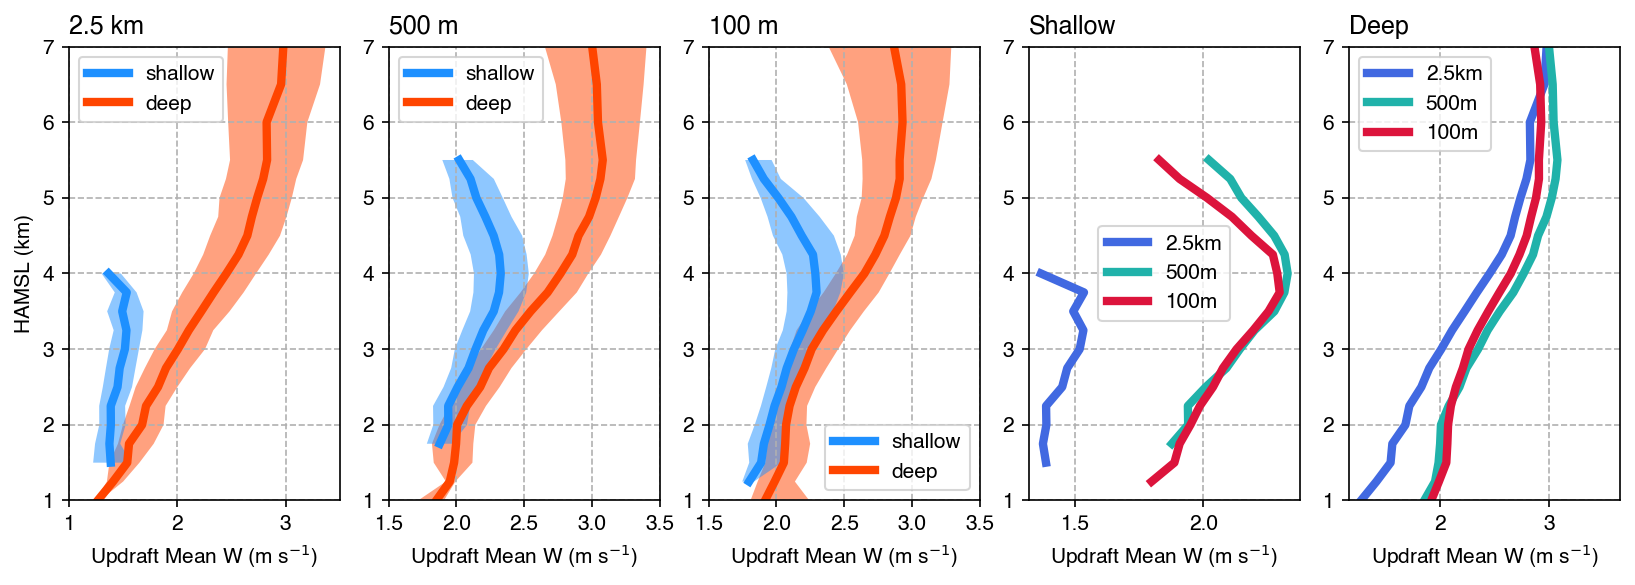

In [336]:
min_ns_shallow = 10
min_ns_deep = 10

# Convert CoreArea to CoreDiameter, filter heights with low samples
prof_s_d2 = np.sqrt(trackmax_CoreMeanWUp_shallow_prof_pts_d2.where(track_ns_init_shallow_d2 >= min_ns_shallow)/np.pi)*2
prof_s_d3 = np.sqrt(trackmax_CoreMeanWUp_shallow_prof_pts_d3.where(track_ns_init_shallow_d3 >= min_ns_shallow)/np.pi)*2
prof_s_d4 = np.sqrt(trackmax_CoreMeanWUp_shallow_prof_pts_d4.where(track_ns_init_shallow_d4 >= min_ns_shallow)/np.pi)*2

prof_d_d2 = np.sqrt(trackmax_CoreMeanWUp_deep_prof_pts_d2.where(track_ns_init_deep_d2 >= min_ns_deep)/np.pi)*2
prof_d_d3 = np.sqrt(trackmax_CoreMeanWUp_deep_prof_pts_d3.where(track_ns_init_deep_d3 >= min_ns_deep)/np.pi)*2
prof_d_d4 = np.sqrt(trackmax_CoreMeanWUp_deep_prof_pts_d4.where(track_ns_init_deep_d4 >= min_ns_deep)/np.pi)*2

dict_s = [
    {
        'line':prof_s_d2.sel(quantile=0.5),
        'fill':[prof_s_d2.sel(quantile=0.25), prof_s_d2.sel(quantile=0.75),],
    },
    {
        'line':prof_s_d3.sel(quantile=0.5),
        'fill':[prof_s_d3.sel(quantile=0.25), prof_s_d3.sel(quantile=0.75),],
    },
    {
        'line':prof_s_d4.sel(quantile=0.5),
        'fill':[prof_s_d4.sel(quantile=0.25), prof_s_d4.sel(quantile=0.75),],
    },
]
dict_d = [
    {
        'line':prof_d_d2.sel(quantile=0.5),
        'fill':[prof_d_d2.sel(quantile=0.25), prof_d_d2.sel(quantile=0.75),],
    },
    {
        'line':prof_d_d3.sel(quantile=0.5),
        'fill':[prof_d_d3.sel(quantile=0.25), prof_d_d3.sel(quantile=0.75),],
    },
    {
        'line':prof_d_d4.sel(quantile=0.5),
        'fill':[prof_d_d4.sel(quantile=0.25), prof_d_d4.sel(quantile=0.75),],
    },
]
dict_s_3profs = {'d2':prof_s_d2.sel(quantile=0.5), 'd3':prof_s_d3.sel(quantile=0.5), 'd4':prof_s_d4.sel(quantile=0.5),}
dict_d_3profs = {'d2':prof_d_d2.sel(quantile=0.5), 'd3':prof_d_d3.sel(quantile=0.5), 'd4':prof_d_d4.sel(quantile=0.5),}
legend_ds = {'d2':'2.5km', 'd3':'500m', 'd4':'100m'}
titles = ['2.5 km', '500 m', '100 m', 'Shallow', 'Deep']
ylabels = ['HAMSL (km)', '', '']
xlabels = ['Updraft Mean W (m s$^{-1}$)']*5
xlims = [(1,3.5),(1.5,3.5),(1.5,3.5)]
# xlims = None
ylims = [(1,7)]*3
figsize = (11,4)
fontsize = 10
figname = f'{figdir}Updraft_CoreMeanW_profiles_shallow_deep_d2_d3_d4.png'

# ylims
fig = plot_profiles(1, 3, height, dict_s, dict_d, dict_s_3profs, dict_d_3profs,
                    legend=legend_ds, titles=titles, xlables=xlabels, ylabels=ylabels, xlims=xlims, ylims=ylims, fontsize=fontsize, figsize=figsize, figname=figname)

In [346]:
trackmax_CoreThteMaxUp_deep_prof_pts_d2

<xarray.DataArray 'CoreThteMax_up' (quantile: 3, z: 40)>
array([[          nan,           nan,           nan, 1324.12991333,
        1356.49688721, 1331.65380859, 1333.57543945, 1306.19210815,
        1258.0670166 , 1252.46020508, 1248.41711426, 1247.37304688,
        1243.65161133, 1238.90551758, 1234.72238159, 1233.34179688,
        1231.08709717, 1228.32696533, 1227.13076782, 1224.78253174,
        1224.03894043, 1222.46044922, 1219.93191528, 1219.13751221,
        1219.16708374, 1218.6867981 , 1217.68640137, 1223.50894165,
        1237.42883301, 1271.77453613, 1296.41073608, 1304.45568848,
        1317.20614624, 1320.70962524,           nan,           nan,
                  nan,           nan,           nan,           nan],
       [          nan,           nan,           nan, 1333.37359619,
        1365.47473145, 1359.90039062, 1359.86413574, 1346.35498047,
        1321.95324707, 1313.98083496, 1305.08825684, 1305.13781738,
        1299.00518799, 1295.6383667 , 1289.14544678, 1288.62780762,
        1283.98852539, 1276.66223145, 1275.39019775, 1271.22998047,
        1267.28771973, 1259.57165527, 1252.39678955, 1247.81561279,
        1253.8817749 , 1255.41693115, 1256.05999756, 1265.14385986,
        1281.02990723, 1300.83825684, 1306.29779053, 1310.45178223,
        1321.34228516, 1329.04504395,           nan,           nan,
                  nan,           nan,           nan,           nan],
       [          nan,           nan,           nan, 1342.61727905,
        1388.72741699, 1387.10046387, 1388.15350342, 1372.22854614,
        1355.73083496, 1344.97119141, 1337.35827637, 1334.74487305,
        1333.04153442, 1329.48730469, 1327.20376587, 1325.82214355,
        1323.9413147 , 1320.74066162, 1319.11282349, 1316.08514404,
        1313.94116211, 1310.32250977, 1306.64477539, 1302.82989502,
        1301.14523315, 1299.61154175, 1298.17376709, 1300.48760986,
        1304.00927734, 1312.51739502, 1314.64907837, 1316.5838623 ,
        1329.0975647 , 1353.85031128,           nan,           nan,
                  nan,           nan,           nan,           nan]])
Coordinates:
  * z         (z) float64 250.0 500.0 750.0 1e+03 ... 1.9e+04 2e+04 2.1e+04
  * quantile  (quantile) float64 0.25 0.5 0.75

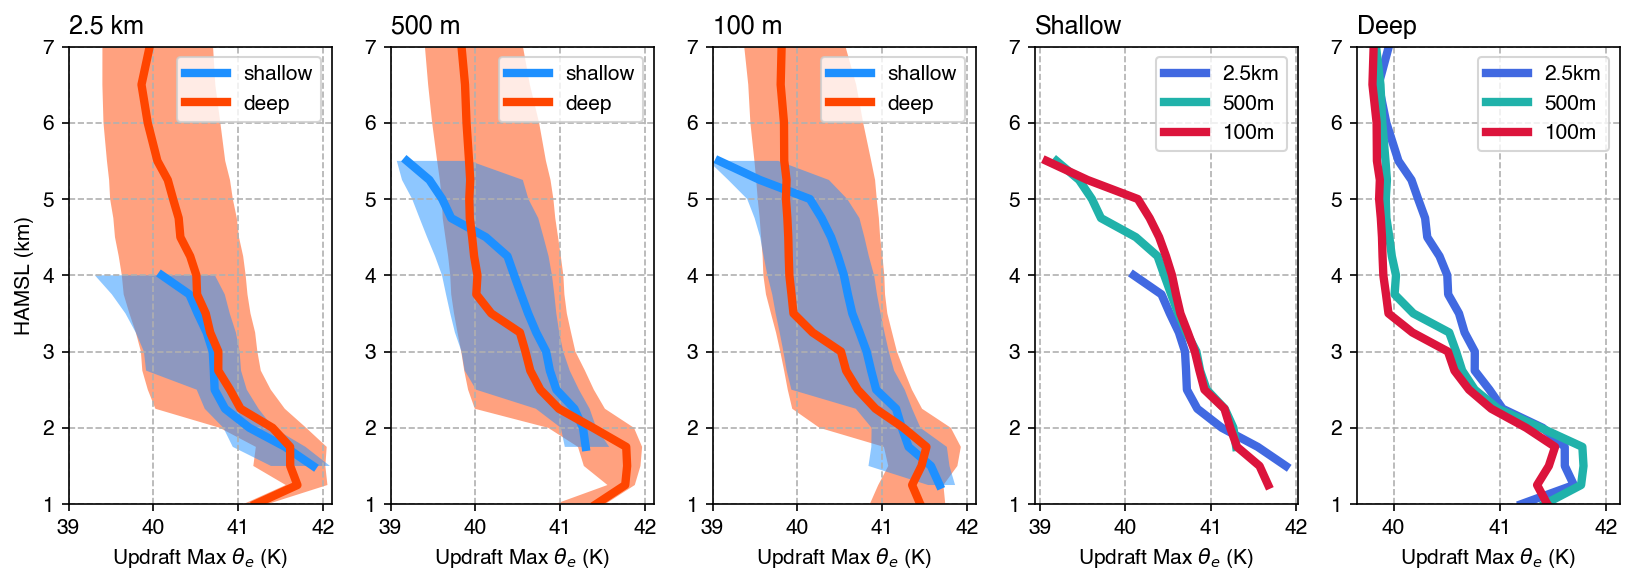

In [340]:
min_ns_shallow = 10
min_ns_deep = 10

# Convert CoreArea to CoreDiameter, filter heights with low samples
prof_s_d2 = np.sqrt(trackmax_CoreThteMaxUp_shallow_prof_pts_d2.where(track_ns_init_shallow_d2 >= min_ns_shallow)/np.pi)*2
prof_s_d3 = np.sqrt(trackmax_CoreThteMaxUp_shallow_prof_pts_d3.where(track_ns_init_shallow_d3 >= min_ns_shallow)/np.pi)*2
prof_s_d4 = np.sqrt(trackmax_CoreThteMaxUp_shallow_prof_pts_d4.where(track_ns_init_shallow_d4 >= min_ns_shallow)/np.pi)*2

prof_d_d2 = np.sqrt(trackmax_CoreThteMaxUp_deep_prof_pts_d2.where(track_ns_init_deep_d2 >= min_ns_deep)/np.pi)*2
prof_d_d3 = np.sqrt(trackmax_CoreThteMaxUp_deep_prof_pts_d3.where(track_ns_init_deep_d3 >= min_ns_deep)/np.pi)*2
prof_d_d4 = np.sqrt(trackmax_CoreThteMaxUp_deep_prof_pts_d4.where(track_ns_init_deep_d4 >= min_ns_deep)/np.pi)*2

dict_s = [
    {
        'line':prof_s_d2.sel(quantile=0.5),
        'fill':[prof_s_d2.sel(quantile=0.25), prof_s_d2.sel(quantile=0.75),],
    },
    {
        'line':prof_s_d3.sel(quantile=0.5),
        'fill':[prof_s_d3.sel(quantile=0.25), prof_s_d3.sel(quantile=0.75),],
    },
    {
        'line':prof_s_d4.sel(quantile=0.5),
        'fill':[prof_s_d4.sel(quantile=0.25), prof_s_d4.sel(quantile=0.75),],
    },
]
dict_d = [
    {
        'line':prof_d_d2.sel(quantile=0.5),
        'fill':[prof_d_d2.sel(quantile=0.25), prof_d_d2.sel(quantile=0.75),],
    },
    {
        'line':prof_d_d3.sel(quantile=0.5),
        'fill':[prof_d_d3.sel(quantile=0.25), prof_d_d3.sel(quantile=0.75),],
    },
    {
        'line':prof_d_d4.sel(quantile=0.5),
        'fill':[prof_d_d4.sel(quantile=0.25), prof_d_d4.sel(quantile=0.75),],
    },
]
dict_s_3profs = {'d2':prof_s_d2.sel(quantile=0.5), 'd3':prof_s_d3.sel(quantile=0.5), 'd4':prof_s_d4.sel(quantile=0.5),}
dict_d_3profs = {'d2':prof_d_d2.sel(quantile=0.5), 'd3':prof_d_d3.sel(quantile=0.5), 'd4':prof_d_d4.sel(quantile=0.5),}
legend_ds = {'d2':'2.5km', 'd3':'500m', 'd4':'100m'}
titles = ['2.5 km', '500 m', '100 m', 'Shallow', 'Deep']
ylabels = ['HAMSL (km)', '', '']
xlabels = ['Updraft Max '+r'$\theta_e$ '+'(K)']*5
xlims = [(39,42.1),(39,42.1),(39,42.1)]
# xlims = None
ylims = [(1,7)]*3
figsize = (11,4)
fontsize = 10
figname = f'{figdir}Updraft_CoreMaxThetaE_profiles_shallow_deep_d2_d3_d4.png'

# ylims
fig = plot_profiles(1, 3, height, dict_s, dict_d, dict_s_3profs, dict_d_3profs,
                    legend=legend_ds, titles=titles, xlables=xlabels, ylabels=ylabels, xlims=xlims, ylims=ylims, fontsize=fontsize, figsize=figsize, figname=figname)

In [122]:
# prof_quantiles = [0.25, 0.5, 0.75]
# trackmax_CoreAreaUp_shallow_d2 = CoreArea_up_shallow_d2.sel(times=slice(0,2)).max(dim='times')
# trackmax_CoreAreaUp_shallow_prof_pts_d2 = trackmax_CoreAreaUp_shallow_d2.quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)
# trackmax_CoreMaxWUp_shallow_d2 = CoreMaxW_up_shallow_d2.sel(times=slice(0,2)).max(dim='times')
# trackmax_CoreMaxWUp_shallow_prof_pts_d2 = trackmax_CoreMaxWUp_shallow_d2.quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)

# trackmax_CoreAreaUp_deep_d2 = CoreArea_up_deep_d2.sel(times=slice(0,2)).max(dim='times')
# trackmax_CoreAreaUp_deep_prof_pts_d2 = trackmax_CoreAreaUp_deep_d2.quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)
# trackmax_CoreMaxWUp_deep_d2 = CoreMaxW_up_deep_d2.sel(times=slice(0,2)).max(dim='times')
# trackmax_CoreMaxWUp_deep_prof_pts_d2 = trackmax_CoreMaxWUp_deep_d2.quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)

In [123]:
# trackmax_CoreAreaUp_shallow_d3 = CoreArea_up_shallow_d3.sel(times=slice(0,2)).max(dim='times')
# trackmax_CoreAreaUp_shallow_prof_pts_d3 = trackmax_CoreAreaUp_shallow_d3.quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)
# trackmax_CoreMaxWUp_shallow_d3 = CoreMaxW_up_shallow_d3.sel(times=slice(0,2)).max(dim='times')
# trackmax_CoreMaxWUp_shallow_prof_pts_d3 = trackmax_CoreMaxWUp_shallow_d3.quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)

# trackmax_CoreAreaUp_deep_d3 = CoreArea_up_deep_d3.sel(times=slice(0,2)).max(dim='times')
# trackmax_CoreAreaUp_deep_prof_pts_d3 = trackmax_CoreAreaUp_deep_d3.quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)
# trackmax_CoreMaxWUp_deep_d3 = CoreMaxW_up_deep_d3.sel(times=slice(0,2)).max(dim='times')
# trackmax_CoreMaxWUp_deep_prof_pts_d3 = trackmax_CoreMaxWUp_deep_d3.quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)

In [124]:
# trackmax_CoreAreaUp_shallow_d4 = CoreArea_up_shallow_d4.sel(times=slice(0,2)).max(dim='times')
# trackmax_CoreAreaUp_shallow_prof_pts_d4 = trackmax_CoreAreaUp_shallow_d4.quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)
# trackmax_CoreMaxWUp_shallow_d4 = CoreMaxW_up_shallow_d4.sel(times=slice(0,2)).max(dim='times')
# trackmax_CoreMaxWUp_shallow_prof_pts_d4 = trackmax_CoreMaxWUp_shallow_d4.quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)

# trackmax_CoreAreaUp_deep_d4 = CoreArea_up_deep_d4.sel(times=slice(0,2)).max(dim='times')
# trackmax_CoreAreaUp_deep_prof_pts_d4 = trackmax_CoreAreaUp_deep_d4.quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)
# trackmax_CoreMaxWUp_deep_d4 = CoreMaxW_up_deep_d4.sel(times=slice(0,2)).max(dim='times')
# trackmax_CoreMaxWUp_deep_prof_pts_d4 = trackmax_CoreMaxWUp_deep_d4.quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)

In [125]:
# # Calculate total number of samples during initial times
# track_ns_init_shallow_d2 = nsample_CoreArea_up_shallow_d2.sel(times=slice(0,2)).sum(dim='times')
# track_ns_init_deep_d2 = nsample_CoreArea_up_deep_d2.sel(times=slice(0,2)).sum(dim='times')

# track_ns_init_shallow_d3 = nsample_CoreArea_up_shallow_d3.sel(times=slice(0,2)).sum(dim='times')
# track_ns_init_deep_d3 = nsample_CoreArea_up_deep_d3.sel(times=slice(0,2)).sum(dim='times')

# track_ns_init_shallow_d4 = nsample_CoreArea_up_shallow_d4.sel(times=slice(0,2)).sum(dim='times')
# track_ns_init_deep_d4 = nsample_CoreArea_up_deep_d4.sel(times=slice(0,2)).sum(dim='times')

In [126]:
# fig, axes = plt.subplots(1, 3, figsize=(10,3), dpi=150, sharey=True)
# axes = axes.ravel()

# ax = axes[0]
# ax.plot(track_ns_init_shallow_d2, height, color='b', label='D2 shallow')
# ax.plot(track_ns_init_deep_d2, height, color='r', label='D2 deep')
# ax.legend()

# ax = axes[1]
# ax.plot(track_ns_init_shallow_d3, height, color='b', label='D3 shallow')
# ax.plot(track_ns_init_deep_d3, height, color='r', label='D3 deep')
# ax.legend()

# ax = axes[2]
# ax.plot(track_ns_init_shallow_d4, height, color='b', label='D4 shallow')
# ax.plot(track_ns_init_deep_d4, height, color='r', label='D4 deep')
# ax.legend()

# plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0, hspace=0)

In [127]:
# track_ns_init_deep_d2

In [128]:
# fig, axes = plt.subplots(1, 3, figsize=(10,3), dpi=150)

# ax = axes[0]
# ax.plot(trackmax_CoreAreaUp_shallow_prof_pts_d2.sel(quantile=0.5).where(track_ns_init_shallow_d2 >= 5), height, color='b', label='D2 shallow')
# ax.plot(trackmax_CoreAreaUp_deep_prof_pts_d2.sel(quantile=0.5).where(track_ns_init_deep_d2 >= 10), height, color='r', label='D2 deep')
# ax.legend()
# ax.set_ylim(1,7)
# ax.set_xlim(10,20)

# ax = axes[1]
# ax.plot(trackmax_CoreAreaUp_shallow_prof_pts_d3.sel(quantile=0.5).where(track_ns_init_shallow_d3 >= 5), height, color='b', label='D3 shallow')
# ax.plot(trackmax_CoreAreaUp_deep_prof_pts_d3.sel(quantile=0.5).where(track_ns_init_deep_d3 >= 10), height, color='r', label='D3 deep')
# ax.legend()
# ax.set_ylim(1,7)
# ax.set_xlim(0,5)

# ax = axes[2]
# ax.plot(trackmax_CoreAreaUp_shallow_prof_pts_d4.sel(quantile=0.5).where(track_ns_init_shallow_d4 >= 5), height, color='b', label='D4 shallow')
# ax.plot(trackmax_CoreAreaUp_deep_prof_pts_d4.sel(quantile=0.5).where(track_ns_init_deep_d4 >= 10), height, color='r', label='D4 deep')
# ax.legend()
# ax.set_ylim(1,7)
# ax.set_xlim(0,5)

In [129]:
# fig, axes = plt.subplots(1, 3, figsize=(10,3), dpi=150)

# ax = axes[0]
# ax.plot(trackmax_CoreMaxWUp_shallow_prof_pts_d2.sel(quantile=0.5).where(track_ns_init_shallow_d2 >= 5), height, color='b', label='D2 shallow')
# ax.plot(trackmax_CoreMaxWUp_deep_prof_pts_d2.sel(quantile=0.5).where(track_ns_init_deep_d2 >= 10), height, color='r', label='D2 deep')
# ax.legend()
# ax.set_ylim(1,7)
# ax.set_xlim(2,10)

# ax = axes[1]
# ax.plot(trackmax_CoreMaxWUp_shallow_prof_pts_d3.sel(quantile=0.5).where(track_ns_init_shallow_d3 >= 5), height, color='b', label='D3 shallow')
# ax.plot(trackmax_CoreMaxWUp_deep_prof_pts_d3.sel(quantile=0.5).where(track_ns_init_deep_d3 >= 10), height, color='r', label='D3 deep')
# ax.legend()
# ax.set_ylim(1,7)
# ax.set_xlim(2,10)

# ax = axes[2]
# ax.plot(trackmax_CoreMaxWUp_shallow_prof_pts_d4.sel(quantile=0.5).where(track_ns_init_shallow_d4 >= 5), height, color='b', label='D4 shallow')
# ax.plot(trackmax_CoreMaxWUp_deep_prof_pts_d4.sel(quantile=0.5).where(track_ns_init_deep_d4 >= 10), height, color='r', label='D4 deep')
# ax.legend()
# ax.set_ylim(1,7)
# ax.set_xlim(2,10)

In [130]:
# prof_quantiles = [0.25, 0.5, 0.75]
# maxCoreAreaUp_shallow_d2 = dss_d2.CoreArea_up.where(max10dbz_d2 <= max10dbz_pts_d2[0], drop=True).isel(core=0).chunk(dict(tracks=-1)).max(dim='times')
# # maxCoreAreaUp_shallow_prof_pts_d2 = maxCoreAreaUp_shallow_d2.quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)
# maxCoreAreaUp_shallow_prof_pts_d2 = maxCoreAreaUp_shallow_d2.where(maxCoreAreaUp_shallow_d2.z <= max10dbz_pts_d2[0]*1000).quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)

In [132]:
# maxCoreAreaUp_deep_d2 = ds_d2.isel(tracks=tid_d2['nms']).CoreArea_up.where(max10dbz_d2 >= max10dbz_pts_d2[2], drop=True).isel(core=0).chunk(dict(tracks=-1)).max(dim='times')
# maxCoreAreaUp_deep_prof_pts_d2 = maxCoreAreaUp_deep_d2.where(maxCoreAreaUp_deep_d2.z <= max10dbz_pts_d2[2]*1000).quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)

In [133]:
# ds_d2.isel(tracks=tid_d2['nms']).CoreArea_up.where(max10dbz_d2 <= max10dbz_pts_d2[0])

In [134]:
# maxCoreAreaUp_shallow_prof_pts_d2.sel(quantile=0.5).plot()
# maxCoreAreaUp_deep_prof_pts_d2.sel(quantile=0.5).plot()

In [135]:
# maxCoreAreaUp_shallow_prof_pts_d2.sel(quantile=0.75).plot()

In [136]:
# max10dbz_d2

In [137]:
# CoreAreaUp_shallow_d2 = ds_d2.isel(tracks=tid_d2['nms']).CoreArea_up.where(max10dbz_d2 <= max10dbz_pts_d2[0], drop=True).isel(core=0).chunk(dict(tracks=-1))
# CoreAreaUp_deep_d2 = ds_d2.isel(tracks=tid_d2['nms']).CoreArea_up.where(max10dbz_d2 >= max10dbz_pts_d2[2], drop=True).isel(core=0).chunk(dict(tracks=-1))

In [138]:
# CoreAreaUp_deep_d2 = ds_d2.isel(tracks=tid_d2['nms']).CoreArea_up.where(max10dbz_d2 >= max10dbz_pts_d2[2], drop=True).isel(core=0).load()

In [139]:
# # ds_d2.times
# time_res = 5.0  # [min]
# xtime = ds_d2.times * time_res
# height = ds_d2.z / 1000.